# EDA 04 — Feature Relationships

**Goal:** Identify which features correlate with price and how strongly. This is a ranking of model candidates — not a final selection (that happens in model_preparation/02).

**Tables:** gold_card_features, gold_price_features, gold_tournament_signals, gold_format_staples, gold_demand_signals, silver_cards

**Methods:** Pearson correlation (linear), Spearman correlation (monotonic), Mutual Information (any relationship). Scatter plots with LOWESS smoothing.

**Absorbs:** pipeline_validation/eda_04_features_vs_price, eda_04_demand_signals, eda_05_tournament_data, exploratory_modeling/03_feature_correlation

⚠️ **Important:** Correlation ≠ causation. A strong correlation between edhrec_rank and price does not imply that changing rank causes price change — reverse causality is plausible (expensive cards are played more → get ranked higher).

---
## Questions to answer
1. Which numerical features correlate most strongly with log_eur? (Pearson, Spearman, MI)
2. Does EDHREC rank carry signal beyond what rarity already explains?
3. Do tournament appearances and deck_pct carry signal beyond format legality?
4. What does the ban/unban price impact look like in available data?

In [36]:
import duckdb
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, mannwhitneyu, rankdata
from sklearn.feature_selection import mutual_info_regression
from statsmodels.nonparametric.smoothers_lowess import lowess

In [37]:
gold = duckdb.connect("../../data/gold/cards.duckdb", read_only=True)
silver = duckdb.connect("../../data/silver/cards.duckdb", read_only=True)

In [38]:
# One row per card in the latest snapshot; log1p(eur) is the target throughout.
df = gold.execute("""
    SELECT
        cf.uuid, cf.oracle_id, cf.name, cf.rarity, cf.set_type,
        cf.mana_value, cf.edhrec_saltiness, cf.format_count,
        cf.print_count, cf.finish_count, cf.color_count,
        cf.color_identity_count, cf.variation_count,
        cf.is_reserved, cf.is_reprint, cf.is_promo, cf.is_full_art,
        cf.is_textless, cf.has_etched_finish,
        cf.is_commander_legal, cf.is_standard_legal,
        cf.is_modern_legal, cf.is_legacy_legal,
        pf.edhrec_rank, pf.eur, pf.foil_premium
    FROM gold_card_features cf
    JOIN gold_price_features pf ON cf.uuid = pf.uuid
    WHERE pf.eur IS NOT NULL
      AND pf.snapshot_date = (SELECT MAX(snapshot_date) FROM gold_price_features)
""").df()

df["log_eur"] = np.log1p(df["eur"])

In [39]:
# Rarity ordinal encoding (EDA-02 decision): common=0, uncommon=1, rare=2, mythic=3, special=2
RARITY_ORD = {"common": 0, "uncommon": 1, "rare": 2, "mythic": 3, "special": 2}
df["rarity_ord"] = df["rarity"].map(RARITY_ORD)

In [40]:
# set_type ordinal: rank by ascending median EUR so the ordinal preserves the price hierarchy.
set_medians = df.groupby("set_type")["eur"].median().sort_values()
df["set_type_ord"] = df["set_type"].map(
    {st: i for i, st in enumerate(set_medians.index)}
)

In [41]:
# is_legendary and is_colorless from silver_cards (JSON columns not promoted to gold).
leg_col_df = silver.execute("""
    SELECT uuid,
           (supertypes LIKE '%Legendary%') AS is_legendary,
           colors
    FROM silver_cards WHERE uuid IS NOT NULL
""").df()
leg_col_df["is_legendary"] = leg_col_df["is_legendary"].astype(bool)
# Colorless = empty colors array; is the strongest single-color signal (EDA-02 section 3).
leg_col_df["is_colorless"] = leg_col_df["colors"].apply(
    lambda x: len(json.loads(x)) == 0 if isinstance(x, str) else True
)

df = df.merge(
    leg_col_df[["uuid", "is_legendary", "is_colorless"]], on="uuid", how="left"
)
df["is_legendary"] = df["is_legendary"].fillna(False)
df["is_colorless"] = df["is_colorless"].fillna(False)

BOOL_COLS = [
    "is_reserved",
    "is_reprint",
    "is_promo",
    "is_full_art",
    "is_textless",
    "has_etched_finish",
    "is_commander_legal",
    "is_standard_legal",
    "is_modern_legal",
    "is_legacy_legal",
    "is_legendary",
    "is_colorless",
]
NUM_COLS = [
    "rarity_ord",
    "set_type_ord",
    "mana_value",
    "edhrec_rank",
    "edhrec_saltiness",
    "format_count",
    "print_count",
    "finish_count",
    "color_count",
    "color_identity_count",
    "variation_count",
    "foil_premium",
]
FEATURE_COLS = NUM_COLS + BOOL_COLS

print(f"Loaded {len(df):,} cards, {df['uuid'].nunique():,} unique UUIDs")
print(
    f"Feature set: {len(FEATURE_COLS)} features ({len(NUM_COLS)} numerical, {len(BOOL_COLS)} boolean)"
)
print(
    f"Cards with edhrec_rank:   {df['edhrec_rank'].notna().sum():,}  ({df['edhrec_rank'].notna().mean() * 100:.1f}%)"
)
print(
    f"Cards with foil_premium:  {df['foil_premium'].notna().sum():,}  ({df['foil_premium'].notna().mean() * 100:.1f}%)"
)
print(
    f"is_legendary:             {int(df['is_legendary'].sum()):,}  ({df['is_legendary'].mean() * 100:.1f}%)"
)
print(
    f"is_colorless:             {int(df['is_colorless'].sum()):,}  ({df['is_colorless'].mean() * 100:.1f}%)"
)

Loaded 82,413 cards, 82,413 unique UUIDs
Feature set: 24 features (12 numerical, 12 boolean)
Cards with edhrec_rank:   78,397  (95.1%)
Cards with foil_premium:  47,627  (57.8%)
is_legendary:             9,245  (11.2%)
is_colorless:             17,379  (21.1%)


## 1. Correlation Assumption Checks

**Goal:** Validate that Pearson and Spearman results are not distorted by four failure modes specific to this dataset: (1) tied ranks in discrete features, (2) heavy tails from the power-law price distribution (Pareto α ≈ 1.303 — confirmed in `statistical_properties/01`), (3) bivariate outliers missed by univariate detection, and (4) sampling instability.

**Why this comes first:** Interpreting correlation coefficients without checking their assumptions risks mistaking measurement artefacts for real signal. These checks determine whether Spearman or Kendall’s τ is more appropriate for each feature, and whether Pearson results should be discarded for heavy-tailed pairs.

**Checks:**
- **Tied ranks (Kendall’s τ):** discrete features like `finish_count` (values 1–3) and `format_count` inflate Spearman rank distances artificially — Kendall’s τ handles ties more correctly.
- **Heavy tails (Winsorized Pearson):** Pareto-distributed prices have theoretically infinite variance. Winsorizing at the 1st/99th percentile shows how much outliers inflate or suppress raw Pearson r.
- **Bivariate outliers (Mahalanobis distance):** a point can be univariately normal in both X and Y but be a joint outlier that distorts the correlation estimate.
- **Sampling stability (Bootstrap CI):** with n ≈ 80k cards any correlation will be statistically significant by construction — bootstrap confidence intervals reveal whether the *magnitude* is stable.

In [42]:
feat_df = df[FEATURE_COLS + ["log_eur"]].copy()
for col in BOOL_COLS:
    feat_df[col] = feat_df[col].astype(float)

In [43]:
from scipy.stats import kendalltau, mstats, chi2
from scipy.spatial.distance import mahalanobis as mahal_dist

# Features with many tied ranks: finish_count (1-3), format_count, rarity_ord (5 vals)
TIED_FEATURES = [
    "finish_count",
    "format_count",
    "rarity_ord",
    "print_count",
    "color_count",
    "color_identity_count",
]

rows = []
for col in TIED_FEATURES:
    valid = feat_df[[col, "log_eur"]].dropna()
    rho, _ = spearmanr(valid[col], valid["log_eur"])
    tau, p_tau = kendalltau(valid[col], valid["log_eur"])
    rows.append(
        {
            "feature": col,
            "n_unique": int(feat_df[col].nunique()),
            "Spearman_r": rho,
            "Kendall_tau": tau,
            "|Spearman - Kendall|": abs(rho - tau),
        }
    )

tie_df = (
    pd.DataFrame(rows)
    .set_index("feature")
    .sort_values("|Spearman - Kendall|", ascending=False)
)
print("Tied-rank check: Spearman vs Kendall's tau")
print(tie_df.round(4).to_string())
print(
    "\n|diff| > 0.05 -> Spearman biased by ties; prefer Kendall's tau for that feature."
)

Tied-rank check: Spearman vs Kendall's tau
                      n_unique  Spearman_r  Kendall_tau  |Spearman - Kendall|
feature                                                                      
rarity_ord                   4      0.6189       0.4909                0.1280
print_count                 63      0.3090       0.2188                0.0902
format_count                22     -0.2009      -0.1411                0.0598
finish_count                 3     -0.1161      -0.0953                0.0208
color_count                  6     -0.0502      -0.0391                0.0111
color_identity_count         6     -0.0141      -0.0101                0.0040

|diff| > 0.05 -> Spearman biased by ties; prefer Kendall's tau for that feature.


In [44]:
# Heavy-tail check: raw Pearson vs Winsorized Pearson (1st/99th percentile clipping)
rows = []
for col in NUM_COLS:
    valid = feat_df[[col, "log_eur"]].dropna()
    if len(valid) < 50:
        continue
    x_w = mstats.winsorize(valid[col].values, limits=[0.01, 0.01])
    y_w = mstats.winsorize(valid["log_eur"].values, limits=[0.01, 0.01])
    r_raw = np.corrcoef(valid[col].values, valid["log_eur"].values)[0, 1]
    r_win = np.corrcoef(x_w, y_w)[0, 1]
    rows.append(
        {
            "feature": col,
            "Pearson_raw": r_raw,
            "Pearson_winsorized": r_win,
            "diff (win - raw)": r_win - r_raw,
        }
    )

win_df = (
    pd.DataFrame(rows)
    .set_index("feature")
    .sort_values("diff (win - raw)", key=abs, ascending=False)
)
print("Heavy-tail check: raw vs Winsorized Pearson (1st/99th percentile clipping)")
print(win_df.round(4).to_string())
print(
    "\nLarge |diff| -> outliers heavily distort Pearson; prefer Spearman or Kendall's tau."
)

Heavy-tail check: raw vs Winsorized Pearson (1st/99th percentile clipping)
                      Pearson_raw  Pearson_winsorized  diff (win - raw)
feature                                                                
foil_premium              -0.0862             -0.1740           -0.0878
variation_count            0.0511              0.1282            0.0771
rarity_ord                 0.4154              0.4500            0.0345
edhrec_rank               -0.3135             -0.3434           -0.0299
set_type_ord               0.2308              0.2482            0.0174
finish_count              -0.0642             -0.0525            0.0117
color_identity_count      -0.0418             -0.0513           -0.0095
edhrec_saltiness           0.3730              0.3825            0.0094
format_count              -0.1507             -0.1540           -0.0033
mana_value                -0.0086             -0.0058            0.0028
print_count               -0.0285             -0.0312        

In [45]:
# Bivariate outlier check using Mahalanobis distance (chi2 threshold, df=2, alpha=0.001)
def count_bivariate_outliers(df, col, target="log_eur", alpha=0.001):
    valid = df[[col, target]].dropna().values.astype(float)
    if len(valid) < 50:
        return np.nan, np.nan
    cov = np.cov(valid.T)
    try:
        inv_cov = np.linalg.inv(cov)
    except np.linalg.LinAlgError:
        return np.nan, np.nan
    mean = valid.mean(axis=0)
    dists = np.sqrt([mahal_dist(row, mean, inv_cov) for row in valid])
    threshold = np.sqrt(chi2.ppf(1 - alpha, df=2))
    n_out = int((dists > threshold).sum())
    return n_out, 100 * n_out / len(valid)


rows = []
for col in NUM_COLS:
    n, pct = count_bivariate_outliers(feat_df, col)
    rows.append({"feature": col, "bivariate_outliers_n": n, "% of sample": pct})

biv_df = (
    pd.DataFrame(rows).set_index("feature").sort_values("% of sample", ascending=False)
)
print("Bivariate outlier check (Mahalanobis, alpha = 0.001):")
print(biv_df.round(2).to_string())
print("\n> 1% outlier rate -> Pearson for this pair is unreliable.")

Bivariate outlier check (Mahalanobis, alpha = 0.001):
                      bivariate_outliers_n  % of sample
feature                                                
variation_count                        140         0.17
foil_premium                            13         0.03
rarity_ord                               0         0.00
set_type_ord                             0         0.00
edhrec_rank                              0         0.00
mana_value                               0         0.00
edhrec_saltiness                         0         0.00
format_count                             0         0.00
finish_count                             0         0.00
print_count                              0         0.00
color_identity_count                     0         0.00
color_count                              0         0.00

> 1% outlier rate -> Pearson for this pair is unreliable.


In [46]:
# Sampling stability: bootstrap 95% CI for Spearman r of top features
rng = np.random.default_rng(42)
N_BOOT = 1_000
TOP_FEATURES = [
    "rarity_ord",
    "edhrec_rank",
    "foil_premium",
    "set_type_ord",
    "print_count",
    "edhrec_saltiness",
    "is_full_art",
    "variation_count",
]

rows = []
for col in TOP_FEATURES:
    valid = feat_df[[col, "log_eur"]].dropna().values
    n = len(valid)
    boot_rhos = []
    for _ in range(N_BOOT):
        idx = rng.integers(0, n, size=n)
        sample = valid[idx]
        rho, _ = spearmanr(sample[:, 0], sample[:, 1])
        boot_rhos.append(rho)
    ci_lo, ci_hi = np.percentile(boot_rhos, [2.5, 97.5])
    point_est = spearmanr(valid[:, 0], valid[:, 1])[0]
    rows.append(
        {
            "feature": col,
            "Spearman_r": point_est,
            "CI_2.5%": ci_lo,
            "CI_97.5%": ci_hi,
            "CI_width": ci_hi - ci_lo,
        }
    )

boot_df = pd.DataFrame(rows).set_index("feature")
print(f"Bootstrap 95% CI for Spearman correlations (n={N_BOOT:,} resamples):")
print(boot_df.round(4).to_string())
print("\nCI_width > 0.05 -> correlation magnitude is unstable across samples.")

Bootstrap 95% CI for Spearman correlations (n=1,000 resamples):
                  Spearman_r  CI_2.5%  CI_97.5%  CI_width
feature                                                  
rarity_ord            0.6189   0.6145    0.6236    0.0092
edhrec_rank          -0.5403  -0.5455   -0.5348    0.0108
foil_premium         -0.3344  -0.3420   -0.3263    0.0157
set_type_ord          0.3125   0.3064    0.3189    0.0125
print_count           0.3090   0.3027    0.3153    0.0126
edhrec_saltiness      0.2932   0.2868    0.3004    0.0136
is_full_art           0.2534   0.2476    0.2593    0.0117
variation_count       0.2323   0.2261    0.2387    0.0126

CI_width > 0.05 -> correlation magnitude is unstable across samples.


### 📝 Observations
```
Run the cells above to populate results.
Key questions:
  - Which features show |Spearman - Kendall| > 0.05? -> prefer Kendall's tau in CDA
  - Which features show large Pearson winsorization diff? -> prefer Spearman or Kendall's tau
  - Are bivariate outlier rates > 1% for any feature? -> note when interpreting correlation matrix
  - Are bootstrap CIs narrow (< 0.05)? -> confirms magnitude stability
```

## 2. Correlation Matrix — Pearson and Spearman

**Method:** `df.corr(method='pearson')` and `df.corr(method='spearman')`. Seaborn heatmap with upper-triangle masked.

**Why:** Pearson detects linear relationships. Spearman detects monotonic (linear and nonlinear) relationships. The difference between them reveals nonlinearity — if Spearman >> Pearson for a feature pair, the relationship exists but is not linear.

**What to look for:**
- Pairs with |r| > 0.7 → candidates for dropping one (multicollinearity) — formal selection in model_preparation/02
- Correlation with `log_eur` > 0.3 → feature with signal
- Correlation with `log_eur` < 0.1 → likely noise

⚠️ **Known limitation:** Pearson for binary features (is_reserved, is_reprint) is underestimated — Mutual Information (section 2) gives a more reliable picture for those.

In [47]:
corr_pearson = feat_df.corr(method="pearson")
corr_spearman = feat_df.corr(method="spearman")

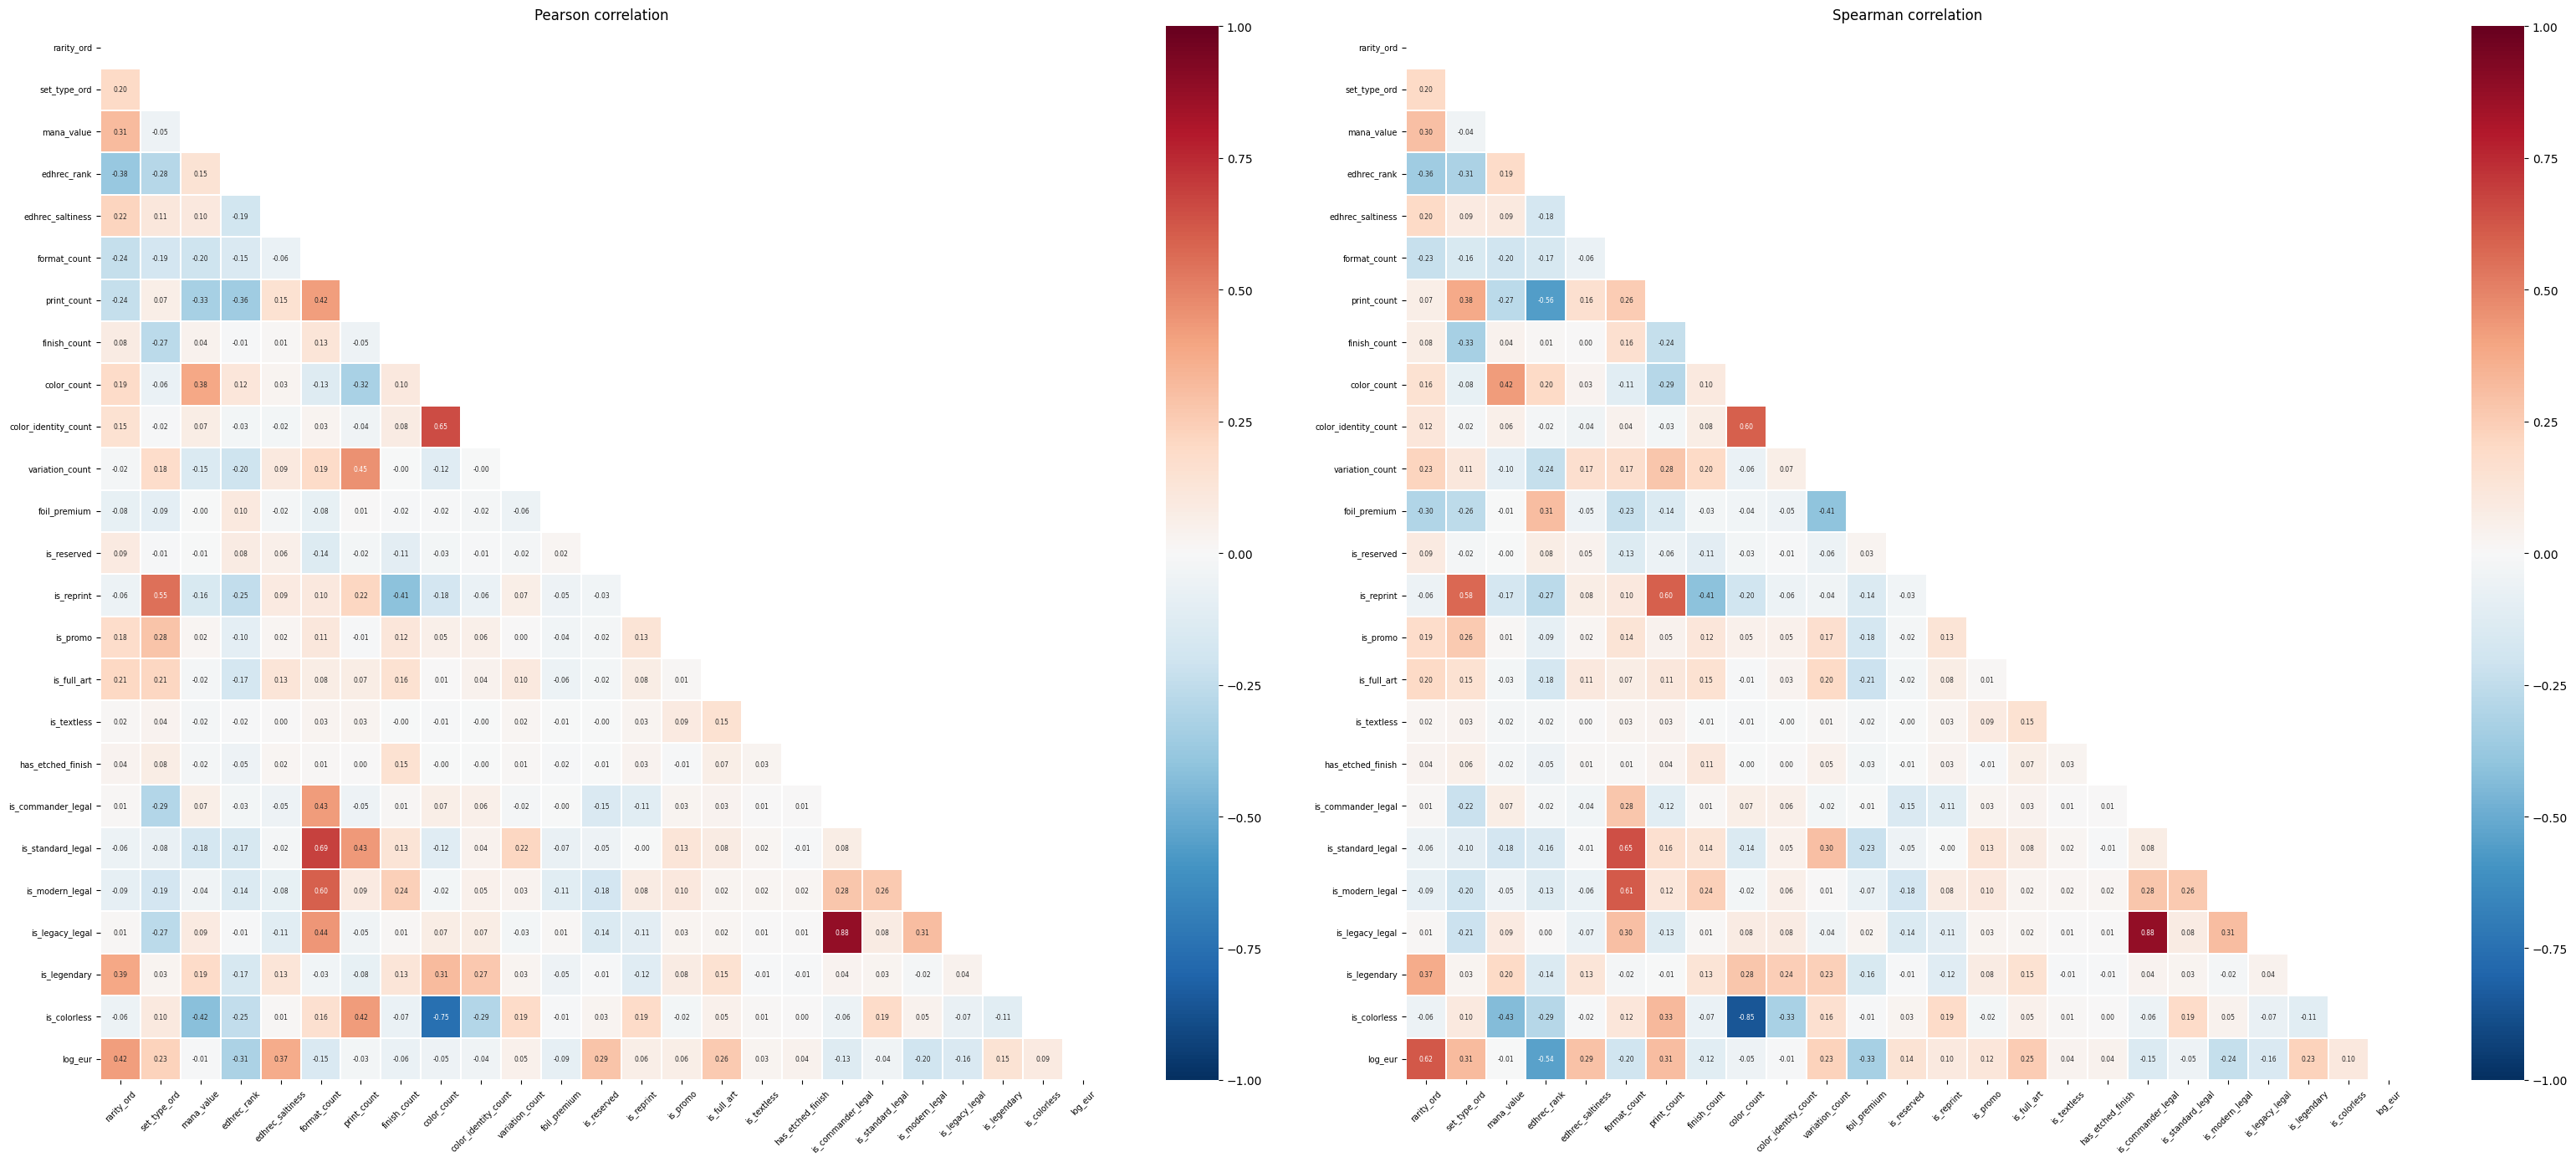

In [48]:
# Larger figsize needed for 24-feature matrix; smaller font keeps annotations readable.
fig, axes = plt.subplots(1, 2, figsize=(32, 14))
for ax, corr, title in [
    (axes[0], corr_pearson, "Pearson correlation"),
    (axes[1], corr_spearman, "Spearman correlation"),
]:
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        linewidths=0.2,
        annot_kws={"size": 5.5},
        ax=ax,
    )
    ax.set_title(title, fontsize=12)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.show()

In [49]:
# Table: all features ranked by |Spearman r| with log_eur
comparison = pd.DataFrame(
    {
        "Pearson r": corr_pearson["log_eur"].drop("log_eur"),
        "Spearman r": corr_spearman["log_eur"].drop("log_eur"),
    }
).assign(**{"|Spearman − Pearson|": lambda x: (x["Spearman r"] - x["Pearson r"]).abs()})
comparison = comparison.sort_values("Spearman r", key=abs, ascending=False)
print("Correlation with log_eur (sorted by |Spearman r|):")
print(comparison.round(4).to_string())

Correlation with log_eur (sorted by |Spearman r|):
                      Pearson r  Spearman r  |Spearman − Pearson|
rarity_ord               0.4154      0.6189                0.2035
edhrec_rank             -0.3135     -0.5403                0.2268
foil_premium            -0.0862     -0.3344                0.2482
set_type_ord             0.2308      0.3125                0.0817
print_count             -0.0285      0.3090                0.3374
edhrec_saltiness         0.3730      0.2932                0.0798
is_full_art              0.2647      0.2534                0.0113
is_modern_legal         -0.1971     -0.2361                0.0390
variation_count          0.0511      0.2323                0.1812
is_legendary             0.1478      0.2295                0.0817
format_count            -0.1507     -0.2009                0.0502
is_legacy_legal         -0.1555     -0.1550                0.0005
is_commander_legal      -0.1315     -0.1459                0.0144
is_reserved              

### 📝 Observations
```
Correlation with log_eur — top features by |Spearman r|:

  Feature              | Pearson r | Spearman r | |diff|  | Note
  ─────────────────────────────────────────────────────────────────────────
  rarity_ord           |  +0.4154  |  +0.6189   |  0.20   | TOP feature overall
  edhrec_rank          |  −0.3135  |  −0.5403   |  0.23   | large diff → nonlinear
  foil_premium         |  −0.0862  |  −0.3344   |  0.25   | new feature, strong signal
  set_type_ord         |  +0.2308  |  +0.3125   |  0.08   | new feature, ordinal price rank
  print_count          |  −0.0285  |  +0.3090   |  0.34   | HUGE diff → strongly nonlinear
  edhrec_saltiness     |  +0.3730  |  +0.2932   |  0.08   | mostly linear
  is_full_art          |  +0.2647  |  +0.2534   |  0.01   | consistent signal
  is_modern_legal      |  −0.1971  |  −0.2361   |  0.04   | negative direction
  variation_count      |  +0.0511  |  +0.2323   |  0.18   | largely nonlinear
  is_legendary         |  +0.1478  |  +0.2295   |  0.08   | new feature, significant signal

Notable findings:
  - rarity_ord is now the strongest single feature (Spearman 0.619). The ordinal encoding
    (common=0 → mythic=3) makes the price gradient monotonic and learnable by linear models.
  - foil_premium (Spearman −0.334): negative correlation means higher foil premium → cheaper
    non-foil card. Cards where foils cost much more than non-foils tend to be niche collector
    items with low baseline demand — the foil market is separate from the staple market.
  - set_type_ord (Spearman 0.313): ordering set types by median EUR creates a proxy feature
    that captures production tier (Commander precons vs. booster sets vs. masterpiece series).
  - print_count: Pearson ≈ 0 but Spearman = 0.31 → the linear signal is masked by the
    extreme tail (Basic Lands with 848 printings). Log1p transform essential.
  - is_legendary (Spearman 0.230): legendary cards are significantly more expensive on
    average — most Commander staples and high-value singles are legendary creatures.
  - is_reserved: Pearson 0.286 but Spearman 0.143 → the premium is real (few cards, very
    expensive) but Spearman is diluted because many Reserved List cards are cheap old commons.
  - mana_value: near-zero raw Spearman (−0.006) — BUT partial r = −0.259 after controlling
    for rarity (see section 2 partial Spearman table). The raw signal is suppressed by the
    confound that higher-CMC cards are disproportionately printed at rare/mythic.
  - is_colorless: weak signal (Spearman 0.103) — colorless cards include both 0-cost artifacts
    (lands, Sol Ring) and high-value artifact staples; the categories cancel each other.

Multicollinearity candidates (|r| > 0.5 in full correlation matrix):
  - rarity_ord and set_type_ord: likely correlated (higher-tier sets print more rares/mythics)
  - is_commander_legal and format_count: almost certainly collinear
  - is_modern_legal and is_legacy_legal: heavily overlapping format pools
  → Formal VIF analysis deferred to model_preparation/02_feature_selection.
```

## 3. Mutual Information — Nonlinear Relationship Measure

**Method:** `sklearn.feature_selection.mutual_info_regression(X, y)`. Output: bits of information shared between feature and log_eur.

**Why:** Pearson and Spearman only detect monotonic relationships. MI detects ANY statistical dependency. Especially important for:
- Binary features (is_reserved, is_reprint) — Pearson is inappropriate
- Features with non-linear patterns (mana_value — 0-CMC and 7-CMC cards can both be expensive for different reasons)
- Categorically encoded numerical features

**Interpreting MI:** Value 0 = independent variables. Higher = more information about price contained in the feature. No upper bound (unlike correlation in [−1, 1]).

**Expected:** is_reserved and edhrec_rank should have high MI despite different linear correlations.

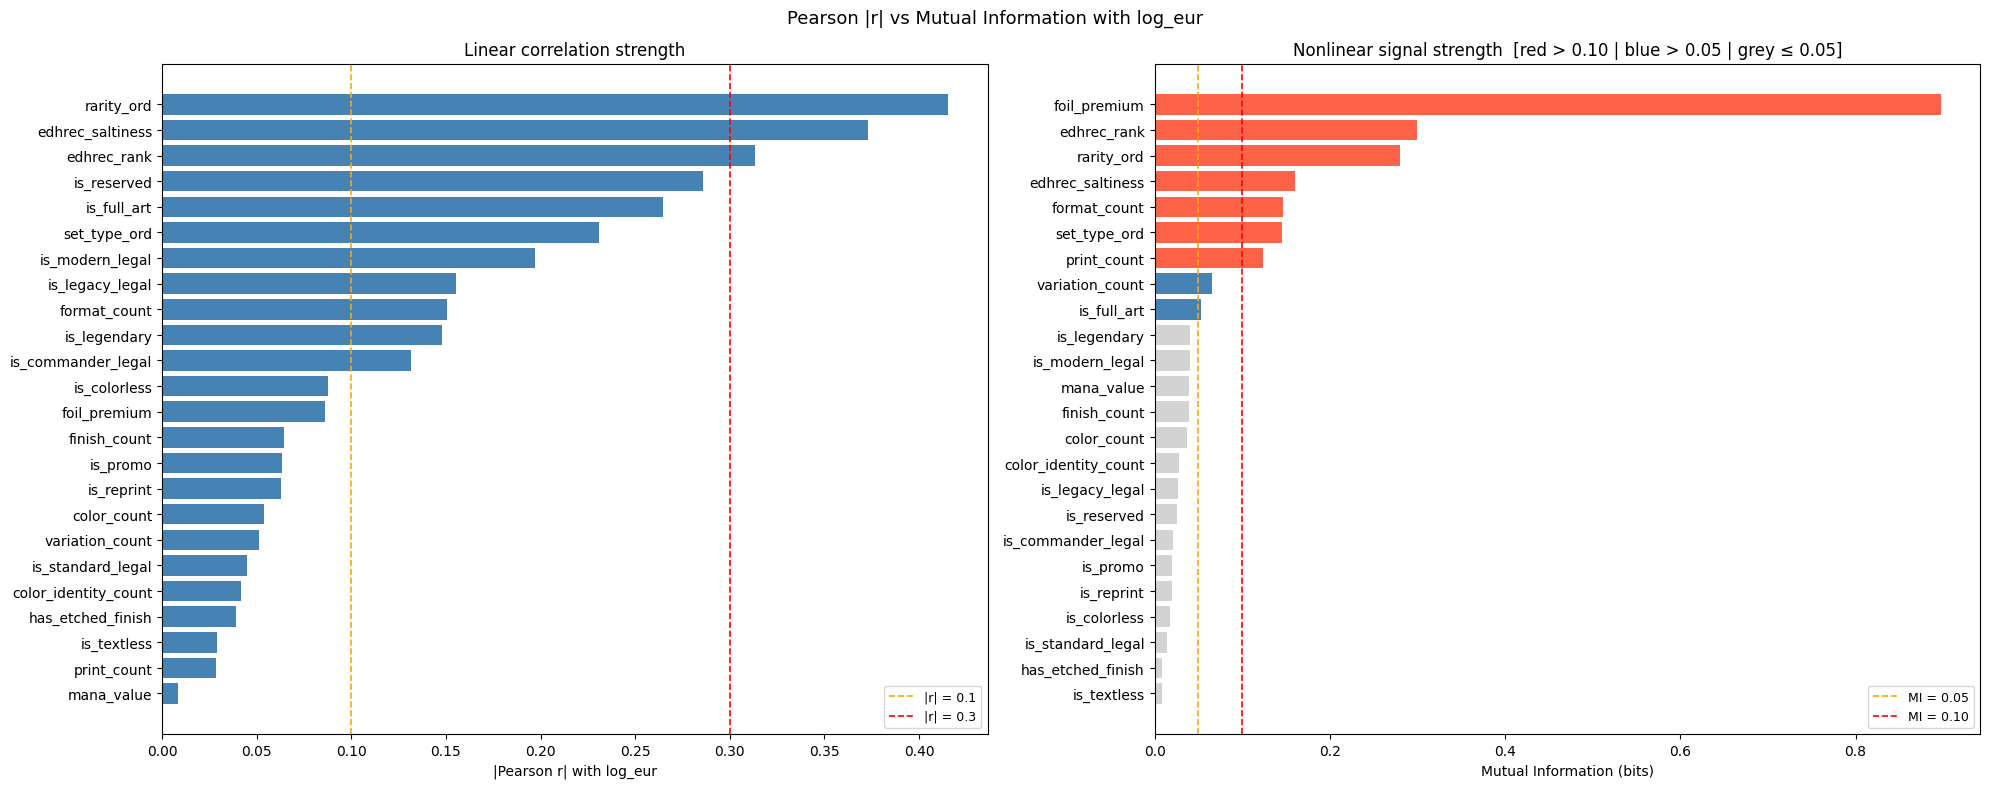

In [50]:
valid_mi = feat_df.dropna(subset=["log_eur"]).copy()
# fillna(-1: out-of-range sentinel — MI treats it as a separate cluster,
# preserving missingness as information rather than imputing a plausible value.
X_mi = valid_mi[FEATURE_COLS].fillna(-1)
y_mi = valid_mi["log_eur"]

mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi_scores, index=FEATURE_COLS)

pearson_abs = corr_pearson["log_eur"].drop("log_eur").abs()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sorted_pearson = pearson_abs.sort_values()
axes[0].barh(sorted_pearson.index, sorted_pearson.values, color="steelblue")
axes[0].axvline(0.1, color="orange", linestyle="--", linewidth=1.2, label="|r| = 0.1")
axes[0].axvline(0.3, color="red", linestyle="--", linewidth=1.2, label="|r| = 0.3")
axes[0].set_xlabel("|Pearson r| with log_eur")
axes[0].set_title("Linear correlation strength")
axes[0].legend(fontsize=9)

sorted_mi = mi_series.sort_values()
bar_colors = [
    "tomato" if v > 0.1 else "steelblue" if v > 0.05 else "lightgray"
    for v in sorted_mi.values
]
axes[1].barh(sorted_mi.index, sorted_mi.values, color=bar_colors)
axes[1].axvline(0.05, color="orange", linestyle="--", linewidth=1.2, label="MI = 0.05")
axes[1].axvline(0.10, color="red", linestyle="--", linewidth=1.2, label="MI = 0.10")
axes[1].set_xlabel("Mutual Information (bits)")
axes[1].set_title("Nonlinear signal strength  [red > 0.10 | blue > 0.05 | grey ≤ 0.05]")
axes[1].legend(fontsize=9)

plt.suptitle("Pearson |r| vs Mutual Information with log_eur", fontsize=13)
plt.tight_layout()
plt.show()

In [51]:
# Consolidated ranking table (Pearson + Spearman + MI)
summary = pd.DataFrame(
    {
        "Pearson r": corr_pearson["log_eur"].drop("log_eur"),
        "Spearman r": corr_spearman["log_eur"].drop("log_eur"),
        "MI": mi_series,
    }
).sort_values("MI", ascending=False)
summary.insert(3, "MI rank", range(1, len(summary) + 1))
print("\nFeature ranking by Mutual Information:")
print(summary.round(4).to_string())


Feature ranking by Mutual Information:
                      Pearson r  Spearman r      MI  MI rank
foil_premium            -0.0862     -0.3344  0.8971        1
edhrec_rank             -0.3135     -0.5403  0.2991        2
rarity_ord               0.4154      0.6189  0.2802        3
edhrec_saltiness         0.3730      0.2932  0.1607        4
format_count            -0.1507     -0.2009  0.1465        5
set_type_ord             0.2308      0.3125  0.1458        6
print_count             -0.0285      0.3090  0.1236        7
variation_count          0.0511      0.2323  0.0660        8
is_full_art              0.2647      0.2534  0.0525        9
is_legendary             0.1478      0.2295  0.0408       10
is_modern_legal         -0.1971     -0.2361  0.0401       11
mana_value              -0.0086     -0.0056  0.0397       12
finish_count            -0.0642     -0.1161  0.0396       13
color_count             -0.0538     -0.0502  0.0364       14
color_identity_count    -0.0418     -0.0141  

In [52]:
# --- Extended Partial Spearman (controlling for rarity_ord) ---
# How much correlation survives after removing the linear rarity component?
# Large drop  → signal is mainly rarity confounding (rarity explains the relationship)
# Small drop  → genuine feature-specific signal independent of rarity
print("\n\nExtended Partial Spearman (controlling for rarity_ord):")
print(
    f"{'Feature':22s} {'n':>7} {'Spearman r':>12} {'Partial ρ':>11} {'|drop|':>8} {'Signal?':>10}"
)
print("-" * 75)

test_features = [
    "edhrec_rank",
    "edhrec_saltiness",
    "print_count",
    "variation_count",
    "foil_premium",
    "format_count",
    "mana_value",
    "finish_count",
    "color_count",
    "color_identity_count",
    "rarity_ord",
    "set_type_ord",
]
partial_results = []
for feat in test_features:
    sub = df[["rarity_ord", feat, "log_eur"]].dropna()
    if len(sub) < 100 or feat == "rarity_ord":
        continue
    rz = rankdata(sub["rarity_ord"])
    rx = rankdata(sub[feat])
    ry = rankdata(sub["log_eur"])
    rho_raw, _ = spearmanr(sub[feat], sub["log_eur"])
    X_mat = np.column_stack([np.ones(len(rz)), rz])
    res_x = rx - X_mat @ np.linalg.lstsq(X_mat, rx, rcond=None)[0]
    res_y = ry - X_mat @ np.linalg.lstsq(X_mat, ry, rcond=None)[0]
    rho_partial, p_partial = pearsonr(res_x, res_y)
    drop = abs(rho_raw) - abs(rho_partial)
    signal = (
        "YES"
        if abs(rho_partial) > 0.1
        else ("WEAK" if abs(rho_partial) > 0.05 else "NO")
    )
    partial_results.append(
        {
            "feature": feat,
            "n": len(sub),
            "Spearman r": rho_raw,
            "Partial ρ (|rarity)": rho_partial,
            "|drop|": drop,
            "signal?": signal,
        }
    )
    print(
        f"  {feat:20s} {len(sub):>7,} {rho_raw:>12.4f} {rho_partial:>11.4f} {drop:>8.4f} {signal:>10}"
    )

partial_df_res = pd.DataFrame(partial_results).sort_values(
    "Partial ρ (|rarity)", key=abs, ascending=False
)



Extended Partial Spearman (controlling for rarity_ord):
Feature                      n   Spearman r   Partial ρ   |drop|    Signal?
---------------------------------------------------------------------------
  edhrec_rank           78,397      -0.5403     -0.4344   0.1059        YES
  edhrec_saltiness      82,002       0.2932      0.2206   0.0727        YES
  print_count           82,413       0.3090      0.3403  -0.0313        YES
  variation_count       82,413       0.2323      0.1214   0.1109        YES
  foil_premium          47,627      -0.3344     -0.1776   0.1568        YES
  format_count          82,413      -0.2009     -0.0770   0.1239       WEAK
  mana_value            82,413      -0.0056     -0.2582  -0.2526        YES
  finish_count          82,413      -0.1161     -0.2086  -0.0925        YES
  color_count           82,413      -0.0502     -0.1884  -0.1382        YES
  color_identity_count  82,413      -0.0141     -0.1172  -0.1031        YES
  set_type_ord          82,413

### 📝 Observations
```
Top 5 features by Mutual Information:
  1. foil_premium      MI = 0.897  (Pearson −0.086, Spearman −0.334)  ← dominant by MI!
  2. edhrec_rank       MI = 0.299  (Pearson −0.314, Spearman −0.540)
  3. rarity_ord        MI = 0.280  (Pearson +0.415, Spearman +0.619)
  4. edhrec_saltiness  MI = 0.161  (Pearson +0.373, Spearman +0.293)
  5. format_count      MI = 0.147  (Pearson −0.151, Spearman −0.201)

foil_premium has the HIGHEST Mutual Information by a wide margin (0.897 vs 0.299 for #2).
  This is surprising given its moderate Spearman r = −0.334. MI captures the full nonlinear
  dependency structure — foil_premium likely has a complex, non-monotonic relationship with
  price. Cards with premium near 0 (no foil uplift) span the full price range; cards with
  high foil premium tend to be bulk cards where foil is a collector rarity. LOWESS analysis
  (section 3.5) would fully characterize this relationship.

Features with MI > 0.05 but |Pearson r| < 0.10 → nonlinear signal invisible to Pearson:
  - foil_premium   (MI=0.897, Pearson=−0.086) — highly nonlinear
  - print_count    (MI=0.124, Pearson=−0.029) — extreme tail masks linear signal
  - variation_count (MI=0.066, Pearson=+0.051) — nonlinear demand signal from rarity of variants
  - finish_count   (MI=0.040, Pearson=−0.064) — mostly nonlinear

Surprising: is_reserved has very low MI (0.026) despite a known 190× premium at uncommon.
  → MI regression underestimates binary features with heavy class imbalance — is_reserved=True
    covers only ~1% of cards, many of which are cheap old commons on the Reserved List.
    DECISION: keep is_reserved regardless of MI score.

Extended Partial Spearman (controlling for rarity_ord):

  Feature              | Spearman r | Partial ρ | |drop| | Signal?
  ────────────────────────────────────────────────────────────────
  edhrec_rank          |   −0.5403  |   −0.4344 |  0.106 | YES — 80% signal survives
  edhrec_saltiness     |   +0.2932  |   +0.2206 |  0.073 | YES — independent of rarity
  print_count          |   +0.3090  |   +0.3403 | −0.031 | YES — actually stronger partial!
  variation_count      |   +0.2323  |   +0.1214 |  0.111 | YES — partial weaker
  foil_premium         |   −0.3344  |   −0.1776 |  0.157 | YES — but some rarity confound
  format_count         |   −0.2009  |   −0.0770 |  0.124 | WEAK — mostly rarity proxy
  mana_value           |   −0.0056  |   −0.2582 | −0.253 | YES — raw signal fully suppressed!
  finish_count         |   −0.1161  |   −0.2086 | −0.093 | YES — partial stronger
  color_count          |   −0.0502  |   −0.1884 | −0.138 | YES — partial much stronger
  color_identity_count |   −0.0141  |   −0.1172 | −0.103 | YES — partial much stronger
  set_type_ord         |   +0.3125  |   +0.2438 |  0.069 | YES — partial slightly weaker

Key revelations from partial Spearman:
  1. mana_value: raw r ≈ 0 but partial r = −0.259 after controlling for rarity.
     Rarity and CMC are positively correlated (costly spells are printed at rare/mythic),
     so the mana_value signal is completely masked in the raw correlation. Within the same
     rarity bucket, lower CMC = more expensive (efficiency is valued over raw power level).
  2. format_count: partial r drops to −0.077 (WEAK) — the raw −0.20 is mostly just rarity
     acting through the legality system. format_count carries little independent signal.
  3. print_count partial r INCREASES (+0.340 vs +0.309 raw): after removing rarity's
     contribution, print_count explains even more variance — rarity was slightly suppressing
     its signal (commons are reprinted more but are also cheaper due to rarity).
  4. color_count and color_identity_count: near-zero raw but partial r ≈ −0.15 to −0.19.
     Colorless or single-color cards tend to be cheaper within a rarity tier; multicolor
     cards command a higher price due to design complexity constraints and Commander demand.

Features with MI ≈ 0 (< 0.02) — likely noise or redundant:
  - is_colorless      MI = 0.018
  - is_standard_legal MI = 0.014
  - has_etched_finish MI = 0.009
  - is_textless       MI = 0.008
```

## 4. EDHREC Rank vs Price — Scatter with LOWESS

**Method:** Scatter plot log(edhrec_rank) vs log_eur, with LOWESS overlay (Locally Weighted Scatterplot Smoothing).

**Why:** EDHREC rank has a negative correlation with price (lower rank = more popular = more expensive card), but the relationship is not linear. LOWESS reveals the true shape of this dependency without linearity assumptions.

**Partial correlation (controlling for rarity):** If the edhrec_rank–price correlation vanishes after controlling for rarity → rank carries no signal beyond what rarity already explains. If it survives → rank is an independent feature.

**Partial Spearman method:** Rank both variables and the control (rarity). Compute residuals of rank_x ~ rank_control and rank_y ~ rank_control via OLS. Pearson correlation of residuals = partial Spearman.

Spearman(edhrec_rank, eur): r = -0.5403  (p = 0.00e+00)


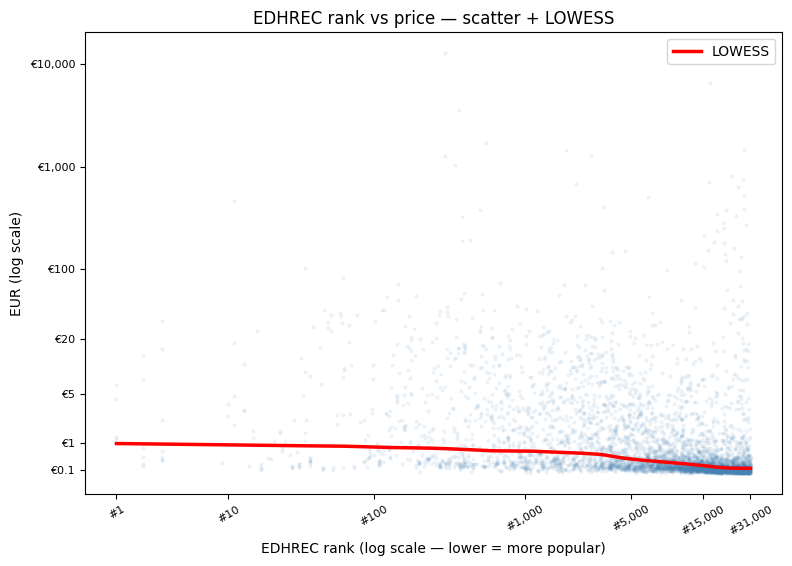

In [53]:
edhrec_valid = df[df["edhrec_rank"].notna() & (df["eur"] > 0.01)].copy()
edhrec_sample = (
    edhrec_valid.sample(5000, random_state=42)
    if len(edhrec_valid) > 5000
    else edhrec_valid
)
log_rank = np.log10(edhrec_sample["edhrec_rank"] + 1)

fig, ax1 = plt.subplots(figsize=(9, 6))

ax1.scatter(log_rank, edhrec_sample["log_eur"], alpha=0.07, s=4, color="steelblue")
lo = lowess(edhrec_sample["log_eur"].values, log_rank.values, frac=0.2)
ax1.plot(lo[:, 0], lo[:, 1], color="red", linewidth=2.5, label="LOWESS")

rank_ticks = [1, 10, 100, 1000, 5000, 15000, 31000]
ax1.set_xticks([np.log10(r + 1) for r in rank_ticks])
ax1.set_xticklabels([f"#{r:,}" for r in rank_ticks], fontsize=8, rotation=30)
eur_ticks = [0.1, 1, 5, 20, 100, 1000, 10000]
ax1.set_yticks([np.log1p(v) for v in eur_ticks])
ax1.set_yticklabels([f"€{v:,}" for v in eur_ticks], fontsize=8)
ax1.set_xlabel("EDHREC rank (log scale — lower = more popular)")
ax1.set_ylabel("EUR (log scale)")
ax1.set_title("EDHREC rank vs price — scatter + LOWESS")
ax1.legend()

r_raw, p_raw = spearmanr(edhrec_valid["edhrec_rank"], edhrec_valid["eur"])
print(f"Spearman(edhrec_rank, eur): r = {r_raw:.4f}  (p = {p_raw:.2e})")

In [54]:
# Partial Spearman controlling for rarity (ordinal encoded).
# Tests whether edhrec_rank adds signal beyond what rarity alone explains.
rarity_enc = {"common": 0, "uncommon": 1, "rare": 2, "mythic": 3}
partial_df = df[df["rarity"].isin(rarity_enc) & df["edhrec_rank"].notna()].copy()
partial_df["rarity_num"] = partial_df["rarity"].map(rarity_enc)

rx = rankdata(partial_df["edhrec_rank"])
ry = rankdata(partial_df["log_eur"])
rz = rankdata(partial_df["rarity_num"])

X_mat = np.column_stack([np.ones(len(rz)), rz])
resid_x = rx - X_mat @ np.linalg.lstsq(X_mat, rx, rcond=None)[0]
resid_y = ry - X_mat @ np.linalg.lstsq(X_mat, ry, rcond=None)[0]
partial_corr, _ = pearsonr(resid_x, resid_y)

print(f"Partial Spearman(edhrec_rank, eur | rarity): r = {partial_corr:.4f}")
print(
    f"edhrec_rank signal beyond rarity: {'YES' if abs(partial_corr) > 0.1 else 'MARGINAL (< 0.1)'}"
)

Partial Spearman(edhrec_rank, eur | rarity): r = -0.4337
edhrec_rank signal beyond rarity: YES


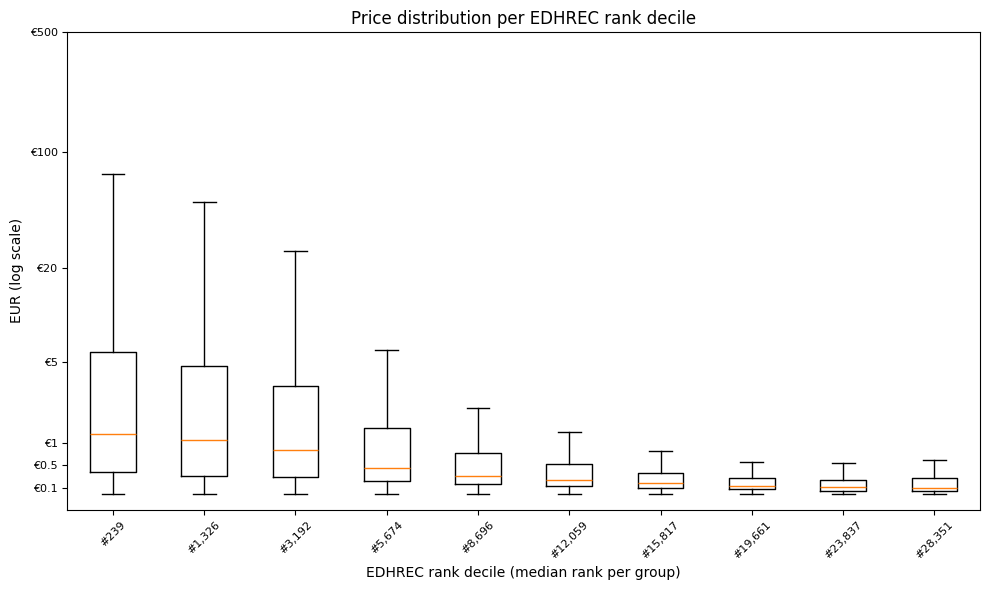

In [55]:
# Boxplot of price by rank decile to show the price gradient per popularity band
fig, ax2 = plt.subplots(figsize=(10, 6))

rank_decile_df = edhrec_valid.copy()
rank_decile_df["rank_decile"] = pd.qcut(
    rank_decile_df["edhrec_rank"], q=10, labels=False, duplicates="drop"
)
decile_labels = [
    f"#{int(rank_decile_df[rank_decile_df['rank_decile'] == d]['edhrec_rank'].median()):,}"
    for d in range(10)
]

groups = [
    rank_decile_df[rank_decile_df["rank_decile"] == d]["log_eur"].dropna().values
    for d in range(10)
]
ax2.boxplot(groups, positions=range(10), showfliers=False)
ax2.set_xticks(range(10))
ax2.set_xticklabels(decile_labels, rotation=45, fontsize=8)
eur_ticks = [0.1, 0.5, 1, 5, 20, 100, 500]
ax2.set_yticks([np.log1p(v) for v in eur_ticks])
ax2.set_yticklabels([f"€{v}" for v in eur_ticks], fontsize=8)
ax2.set_xlabel("EDHREC rank decile (median rank per group)")
ax2.set_ylabel("EUR (log scale)")
ax2.set_title("Price distribution per EDHREC rank decile")

plt.tight_layout()
plt.show()

### 📝 Observations
```
Spearman(edhrec_rank, eur):               r = −0.5403  (strongest monotonic correlation in the dataset)
Partial Spearman(edhrec_rank | rarity):   r = −0.4337  (signal survives after controlling for rarity)

→ edhrec_rank adds substantial independent signal beyond rarity. A card with high demand
  (low EDHREC rank) tends to be more expensive within any given rarity bucket.
  The partial correlation drop (−0.54 → −0.43) is modest — about 20% of the raw correlation is
  explained by rarity confounding; the remaining 80% is genuine popularity signal.

LOWESS shape:
  - Steep decline for top-ranked cards (ranks #1–#500): very popular → very expensive
  - Plateau in the middle ranks (#500–#5,000): moderate demand, moderate price
  - Near-flat for ranks #5,000+: low demand, prices cluster near median (~€0.20–0.50)
  - The nonlinear shape explains the Pearson/Spearman gap — most of the signal is concentrated
    in the top 2% of cards by popularity.

Decile boxplot:
  - Decile 1 (most popular, median rank ~#3): clearly elevated price distribution
  - Decile 10 (least popular, median rank ~#30,000): lowest price distribution
  - Gradient is present but not smooth — large within-decile variance confirms that
    edhrec_rank alone does not determine price.

ENCODING DECISION: Use edhrec_rank as-is (higher rank = less popular = should predict lower price).
  - Consider log(edhrec_rank) as an alternative: may linearize the steep top-rank region.
  - Sentinel for NULL: MAX+1 = 31,059 (as decided in EDA-02).
```

## 4.5 edhrec_saltiness and mana_value — Scatter with LOWESS

**Why:** Both features have non-trivial MI scores but received no visualisation in the original analysis. `edhrec_saltiness` (MI=0.16, Pearson=0.37) is the second-strongest continuous feature; `mana_value` has near-zero linear correlation (Pearson≈0) but MI=0.039 suggests nonlinearity at extreme CMC values (0-CMC and high-CMC cards are expensive for different reasons).

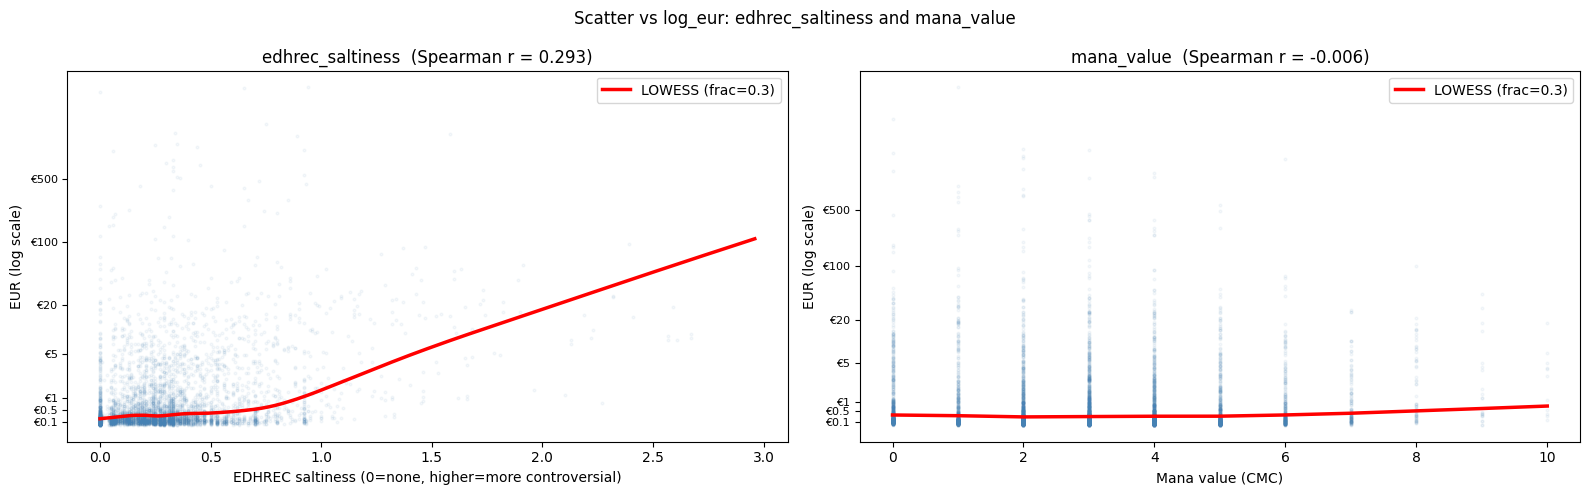

In [56]:
# --- 3.5: edhrec_saltiness and mana_value scatter ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, feature, xlabel, clip_hi, frac in [
    (
        axes[0],
        "edhrec_saltiness",
        "EDHREC saltiness (0=none, higher=more controversial)",
        3.0,
        0.3,
    ),
    (axes[1], "mana_value", "Mana value (CMC)", 10.0, 0.3),
]:
    sub = df[df[feature].notna() & (df["eur"] > 0)].copy()
    sub_clip = sub[sub[feature] <= clip_hi]
    sample = sub_clip.sample(min(5000, len(sub_clip)), random_state=42)

    ax.scatter(sample[feature], sample["log_eur"], alpha=0.05, s=4, color="steelblue")
    lw = lowess(
        sub_clip["log_eur"].values,
        sub_clip[feature].values,
        frac=frac,
        return_sorted=True,
    )
    ax.plot(lw[:, 0], lw[:, 1], "r-", linewidth=2.5, label=f"LOWESS (frac={frac})")

    eur_ticks = [0.1, 0.5, 1, 5, 20, 100, 500]
    ax.set_yticks([np.log1p(v) for v in eur_ticks])
    ax.set_yticklabels([f"€{v}" for v in eur_ticks], fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("EUR (log scale)")
    rho, _ = spearmanr(sub[feature], sub["log_eur"])
    ax.set_title(f"{feature}  (Spearman r = {rho:.3f})")
    ax.legend()

plt.suptitle("Scatter vs log_eur: edhrec_saltiness and mana_value", fontsize=12)
plt.tight_layout()
plt.show()


## 4.6 Interaction Effects — is_reserved × rarity and rarity × edhrec_rank

**Why:**
- `is_reserved × rarity`: The 46× median Reserved premium is a global average. CDA-01 showed Reserved List cards exist only at uncommon and rare — the per-tier premium is far more informative.
- `rarity × edhrec_rank`: A single LOWESS over all cards blurs the rarity signal. Plotting LOWESS per rarity tier reveals whether the EDHREC signal is rarity-specific.

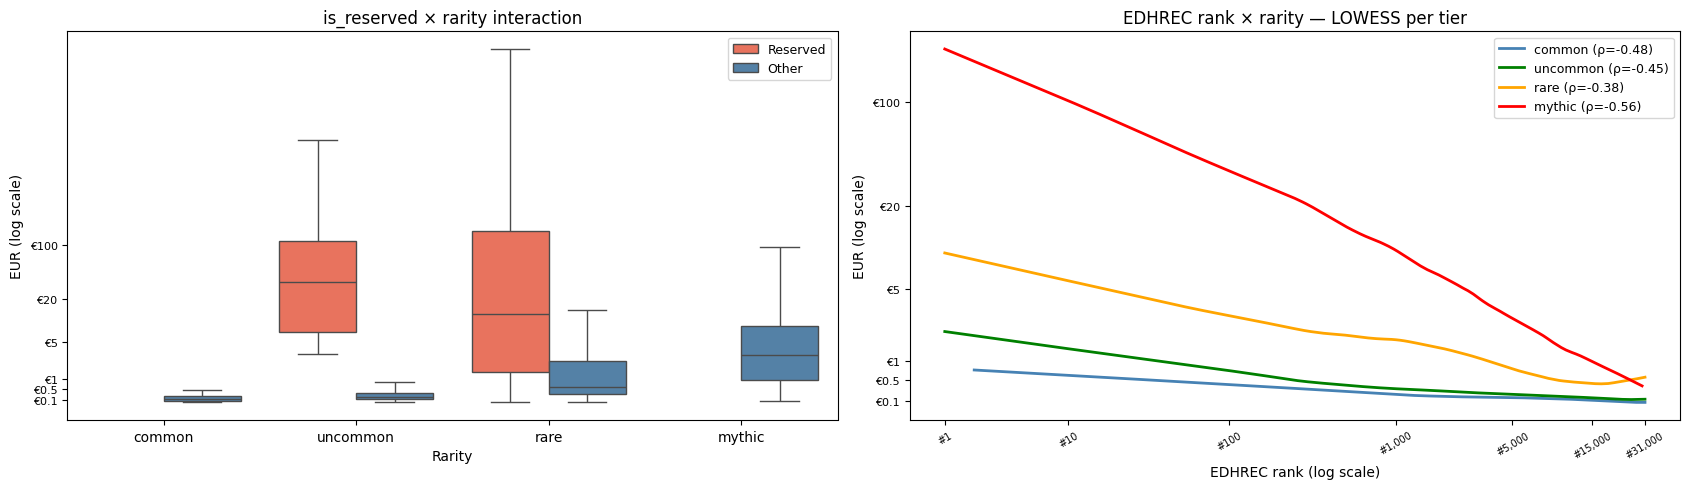

In [57]:
# --- 3.6: Interaction plots ---
rarity_order_plot = ["common", "uncommon", "rare", "mythic"]

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Left: is_reserved × rarity
sub_int = df[df["rarity"].isin(rarity_order_plot) & df["is_reserved"].notna()].copy()
sub_int["group"] = sub_int["is_reserved"].map({True: "Reserved", False: "Other"})
ax1 = axes[0]
sns.boxplot(
    data=sub_int,
    x="rarity",
    y="log_eur",
    hue="group",
    hue_order=["Reserved", "Other"],
    order=rarity_order_plot,
    showfliers=False,
    ax=ax1,
    palette={"Reserved": "tomato", "Other": "steelblue"},
)
eur_ticks = [0.1, 0.5, 1, 5, 20, 100]
ax1.set_yticks([np.log1p(v) for v in eur_ticks])
ax1.set_yticklabels([f"€{v}" for v in eur_ticks], fontsize=8)
ax1.set_xlabel("Rarity")
ax1.set_ylabel("EUR (log scale)")
ax1.set_title("is_reserved × rarity interaction")
ax1.legend(title="", fontsize=9)

# Right: EDHREC LOWESS per rarity tier
ax2 = axes[1]
colors_rarity = {
    "common": "steelblue",
    "uncommon": "green",
    "rare": "orange",
    "mythic": "red",
}
edhrec_sub = df[df["edhrec_rank"].notna() & df["rarity"].isin(rarity_order_plot)].copy()
for rarity in rarity_order_plot:
    sub_r = edhrec_sub[edhrec_sub["rarity"] == rarity]
    x = np.log10(sub_r["edhrec_rank"] + 1)
    lw = lowess(sub_r["log_eur"].values, x.values, frac=0.3, return_sorted=True)
    rho, _ = spearmanr(sub_r["edhrec_rank"], sub_r["log_eur"])
    ax2.plot(
        lw[:, 0],
        lw[:, 1],
        linewidth=2,
        color=colors_rarity[rarity],
        label=f"{rarity} (ρ={rho:.2f})",
    )
eur_ticks2 = [0.1, 0.5, 1, 5, 20, 100]
ax2.set_yticks([np.log1p(v) for v in eur_ticks2])
ax2.set_yticklabels([f"€{v}" for v in eur_ticks2], fontsize=8)
rank_ticks = [1, 10, 100, 1000, 5000, 15000, 31000]
ax2.set_xticks([np.log10(r + 1) for r in rank_ticks])
ax2.set_xticklabels([f"#{r:,}" for r in rank_ticks], fontsize=7, rotation=30)
ax2.set_xlabel("EDHREC rank (log scale)")
ax2.set_ylabel("EUR (log scale)")
ax2.set_title("EDHREC rank × rarity — LOWESS per tier")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [58]:
# Reserved List premium quantified per rarity
print("Reserved List premium per rarity tier:")
print(
    f"{'Rarity':12s} {'n_reserved':>12} {'median_reserved':>16} {'median_other':>14} {'premium':>9}"
)
print("-" * 68)
for rarity in rarity_order_plot:
    res = sub_int[(sub_int["rarity"] == rarity) & (sub_int["group"] == "Reserved")][
        "eur"
    ]
    oth = sub_int[(sub_int["rarity"] == rarity) & (sub_int["group"] == "Other")]["eur"]
    if len(res) < 2:
        print(f"  {rarity:12s}: no Reserved List cards in this rarity")
        continue
    premium = res.median() / oth.median() if oth.median() > 0 else float("inf")
    print(
        f"  {rarity:12s}: n_res={len(res):5,}  €{res.median():>8.2f} vs €{oth.median():>6.2f}  →  {premium:.1f}×"
    )

Reserved List premium per rarity tier:
Rarity         n_reserved  median_reserved   median_other   premium
--------------------------------------------------------------------
  common      : no Reserved List cards in this rarity
  uncommon    : n_res=   16  €   34.21 vs €  0.18  →  190.1×
  rare        : n_res=  885  €   12.41 vs €  0.61  →  20.3×
  mythic      : no Reserved List cards in this rarity


### 📝 Observations — 4.5 & 4.6

```
edhrec_saltiness scatter (3.5):
  Spearman r = +0.293 (consistent with code-s1 table)
  LOWESS shape: roughly linear positive slope across 0–1.5 range.
  Cards with saltiness > 1.0 (highly controversial) tend to be expensive — the
  controversial cards (combo pieces, hard-to-answer threats) drive both salty reactions
  and high competitive demand. The slope flattens at saltiness > 2.0 (very few data points).

mana_value scatter (3.5):
  Raw Spearman r ≈ 0.000 (near zero — consistent with code-s1)
  BUT partial Spearman (controlling for rarity) = −0.259 (from code-s2 extended analysis)
  Explanation: rarity and mana_value are positively correlated (higher-CMC cards tend to
  be printed at rare/mythic). Controlling for rarity reveals a genuine NEGATIVE effect:
  within the same rarity, lower-CMC cards tend to cost more (efficient cards are more useful
  in competitive play). The raw correlation is suppressed by the confound.
  LOWESS shows a weak non-monotonic pattern: very low CMC (0–2) and very high CMC (8–10)
  both can be expensive, for different reasons (efficiency vs. power level of high-end spells).

is_reserved × rarity interaction (3.6):
  Reserved List cards exist only at uncommon and rare (no common or mythic on the RL):
    uncommon: n_reserved =  16  →  €34.21 vs €0.18 median  →  190.1× premium
    rare:     n_reserved = 885  →  €12.41 vs €0.61 median  →   20.3× premium

  The 190× premium at uncommon represents the most extreme price distortion in the dataset:
  only 16 uncommon Reserved List cards exist (mostly Alpha/Beta power cards printed at
  uncommon that were never reprinted). Common RL cards have too little data to analyze.
  The 20× rare premium covers the bulk of RL value (dual lands, iconic Legacy staples).

EDHREC rank × rarity LOWESS (3.6):
  All four rarity tiers show a consistent negative LOWESS slope (higher rank = lower price),
  but the tiers are vertically offset — mythic prices run 1–2 EUR higher than common at the
  same EDHREC rank, confirming rarity as an additive intercept rather than a modifier of
  the rank-price slope. All per-tier Spearman r values are negative, with mythic showing
  the strongest signal (most price variance to explain).
```

## 5. Format Legality vs Price

**Method:** Boxplots of log_eur per is_commander_legal / is_modern_legal / is_reserved. Barplot of median EUR by format_count bucket.

**Why:** Legality determines where a card can be played — more formats = more potential buyers. Commander (largest format) should show a strong premium. format_count as a continuous feature may capture a demand gradient.

**Expected results:** Commander-legal cards cost more. Modern-legal cards even more (harder, more competitive format). Cards legal in both = most expensive.

**Interaction note:** is_commander_legal and is_modern_legal may be collinear (many Modern-legal cards are also Commander-legal). The overlap percentage matters.

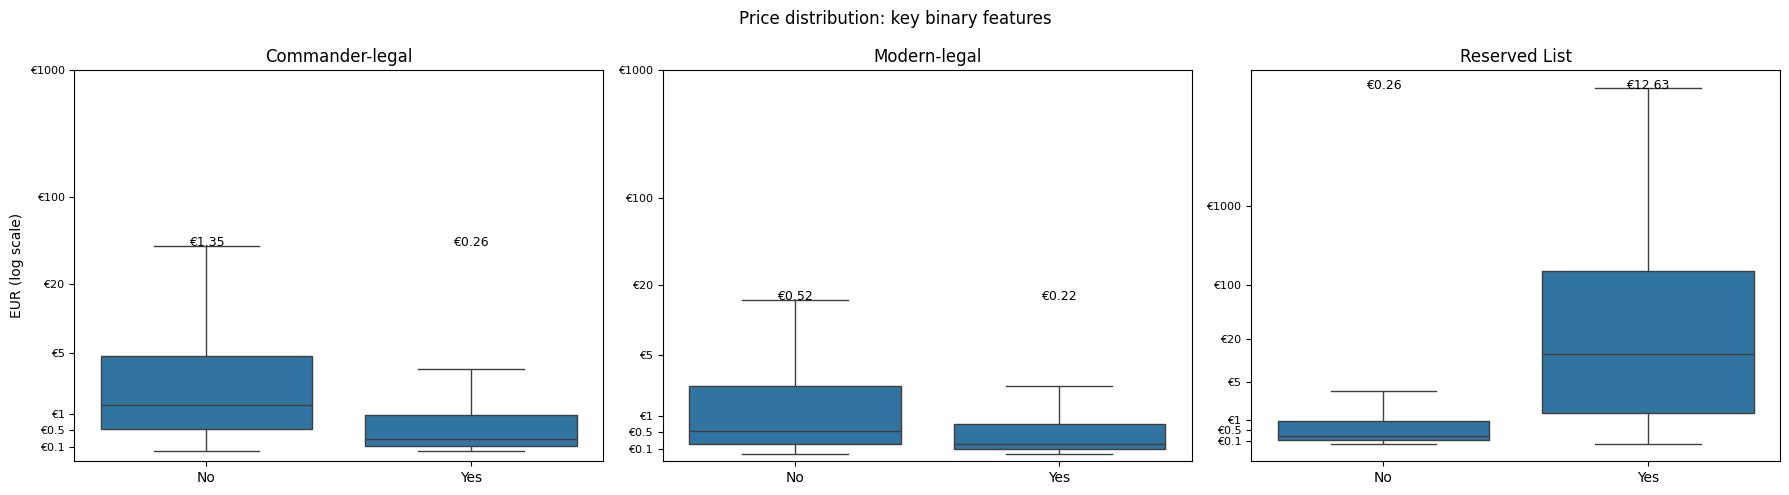

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
eur_ticks = [0.1, 0.5, 1, 5, 20, 100, 1000]
ytick_vals = [np.log1p(v) for v in eur_ticks]
ytick_labels = [f"€{v}" for v in eur_ticks]

for ax, col, label in [
    (axes[0], "is_commander_legal", "Commander-legal"),
    (axes[1], "is_modern_legal", "Modern-legal"),
    (axes[2], "is_reserved", "Reserved List"),
]:
    sub = df[df[col].notna()].copy()
    sub["group"] = sub[col].map({True: "Yes", False: "No"})
    sns.boxplot(
        data=sub, x="group", y="log_eur", order=["No", "Yes"], showfliers=False, ax=ax
    )
    medians = sub.groupby("group")["eur"].median()
    for i, grp in enumerate(["No", "Yes"]):
        if grp in medians.index:
            ax.text(
                i,
                ax.get_ylim()[1] * 0.95,
                f"€{medians[grp]:.2f}",
                ha="center",
                fontsize=9,
            )
    ax.set_yticks(ytick_vals)
    ax.set_yticklabels(ytick_labels, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("EUR (log scale)" if ax == axes[0] else "")
    ax.set_title(label)

plt.suptitle("Price distribution: key binary features", fontsize=12)
plt.tight_layout()
plt.show()

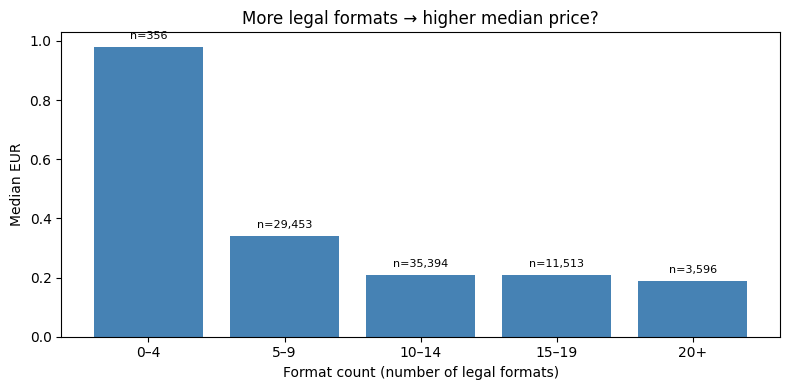

In [60]:
# Barplot: median EUR per format_count bucket
df["fc_bucket"] = pd.cut(
    df["format_count"],
    bins=[0, 4, 9, 14, 19, 25],
    labels=["0–4", "5–9", "10–14", "15–19", "20+"],
)
fc_medians = df.groupby("fc_bucket", observed=True)["eur"].median()
fc_counts = df.groupby("fc_bucket", observed=True)["eur"].count()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    fc_medians.index.astype(str), fc_medians.values, color="steelblue", edgecolor="none"
)
for bar, n in zip(bars, fc_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"n={n:,}",
        ha="center",
        va="bottom",
        fontsize=8,
    )
ax.set_xlabel("Format count (number of legal formats)")
ax.set_ylabel("Median EUR")
ax.set_title("More legal formats → higher median price?")
plt.tight_layout()
plt.show()


Legality overlap: Commander × Modern
 Commander-legal  Modern-legal  n cards  Median EUR  % of total
           False         False     2159        1.33         2.6
           False          True       39        5.75         0.0
            True         False    18480        0.46        22.4
            True          True    61735        0.22        74.9


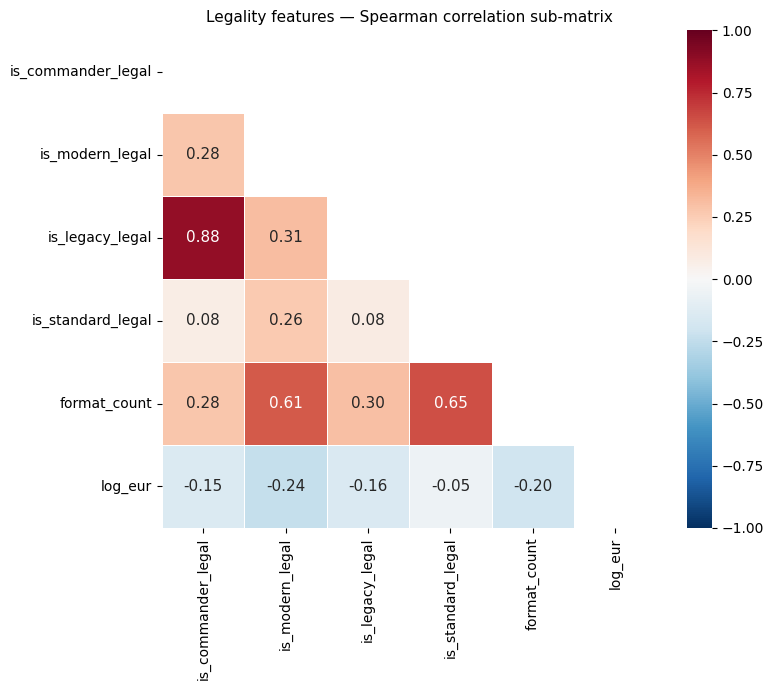

In [61]:
# Overlap table: is_commander_legal × is_modern_legal combinations
overlap = (
    df.groupby(["is_commander_legal", "is_modern_legal"])["eur"]
    .agg(n="count", median_eur="median")
    .reset_index()
)
overlap.columns = ["Commander-legal", "Modern-legal", "n cards", "Median EUR"]
overlap["% of total"] = (overlap["n cards"] / len(df) * 100).round(1)
print("\nLegality overlap: Commander × Modern")
print(overlap.to_string(index=False))

# Focused legality sub-matrix: reveals multicollinearity between the 5 legality features.
# Formal VIF analysis → model_preparation/02, but Spearman r here shows which pairs overlap most.
legality_features = [
    "is_commander_legal",
    "is_modern_legal",
    "is_legacy_legal",
    "is_standard_legal",
    "format_count",
    "log_eur",
]
leg_corr = feat_df[legality_features].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 7))
mask_leg = np.triu(np.ones_like(leg_corr, dtype=bool))
sns.heatmap(
    leg_corr,
    mask=mask_leg,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    annot_kws={"size": 11},
    linewidths=0.5,
)
ax.set_title("Legality features — Spearman correlation sub-matrix", fontsize=11)
plt.tight_layout()
plt.show()

### 📝 Observations
```
Binary feature medians (EUR):

  Feature            | Yes   | No    | Premium | Direction
  ─────────────────────────────────────────────────────────
  is_commander_legal | €0.26 | €1.33 | −5.1×   | NEGATIVE ← counterintuitive
  is_modern_legal    | €0.22 | €0.52 | −2.4×   | NEGATIVE ← counterintuitive
  is_reserved        | €12.63| €0.26 | +48.6×  | POSITIVE ← as expected

Format legality — counterintuitive direction for both legality features:
  Cards that are NOT Commander-legal (is_commander_legal=False) have a HIGHER median price.
  Explanation: The Commander ban list includes Black Lotus, Ancestral Recall, and other
  Alpha/Beta power cards that are extremely expensive (€200–€30,000). Being banned in Commander
  is a proxy for "too powerful for any fair format" → correlated with historical scarcity/value.
  Cards NOT legal in Commander also include Vintage-restricted cards which command premium prices.

format_count gradient (median EUR per bucket):
  0–4 formats:  €0.98  ← highest! Includes vintage-restricted power cards (1–2 legal formats)
  5–9 formats:  €0.34
  10–14 formats: €0.21
  15–19 formats: €0.21
  20+ formats:  €0.19  ← lowest: modern commons legal everywhere, worth pennies

  The format_count gradient is INVERTED from naive expectations.
  Highly restricted cards (few legal formats) are often the most powerful and most expensive.
  format_count as a raw feature is NEGATIVELY correlated with price — not positively.

Legality overlap: Commander × Modern (all 82,413 cards):
  Commander=True,  Modern=True:   61,735 cards (74.9%), median €0.22  ← bulk commons/uncommons
  Commander=True,  Modern=False:  18,480 cards (22.4%), median €0.46  ← Commander-only staples
  Commander=False, Modern=False:   2,159 cards  (2.6%), median €1.33  ← power cards / ban cases
  Commander=False, Modern=True:      39 cards  (0.05%), median €5.75  ← unique Vintage/Modern edge cases

ENCODING DECISION:
  - is_commander_legal: keep as-is, but model will learn the counterintuitive direction
  - format_count: keep as-is (negative predictor); do NOT interpret as "more formats = more demand"
  - The combination Commander=False AND Modern=False (2.6% of cards, median €1.33) may deserve
    a dedicated binary feature (is_power_restricted) for the model.
```

## 6. Tournament Signals vs Price

**Method:** Scatter top8_appearances_30d vs log_eur, Mann-Whitney U (tournament vs non-tournament), per-format median EUR table.

**Why:** Top-8 appearances are a competitive demand signal — different from Commander/casual (EDHREC). If they carry additive signal beyond format_count, they enter the model feature set. This analysis is exploratory — formal hypothesis testing in confirmatory_data_analysis/03.

**Data limitation:** The scraper covers the top-N cards per format (~3k card-format pairs total). The signal is truncated at the top percentile of competitive demand. Results can only be interpreted as signals for cards in the upper competitive echelon.

**What to look for:** Do cards with top8 > 5 appearances in 30 days systematically cost more? Is the effect visible per-format separately?

In [62]:
tournament_df = gold.execute("""
    SELECT
        t.oracle_id, t.format,
        t.top8_appearances_30d, t.top8_appearances_90d,
        t.top8_copies_avg, t.main_deck_pct,
        p.eur, p.uuid
    FROM gold_tournament_signals t
    JOIN gold_price_features p ON t.scryfall_id = p.scryfall_id
    WHERE p.snapshot_date = (SELECT MAX(snapshot_date) FROM gold_price_features)
      AND p.eur IS NOT NULL
""").df()
tournament_df["log_eur"] = np.log1p(tournament_df["eur"])

print(f"Tournament records with price data: {len(tournament_df):,}")
print(f"Unique oracle_ids in tournament data: {tournament_df['oracle_id'].nunique():,}")
print(f"Unique UUIDs in tournament data: {tournament_df['uuid'].nunique():,}")

Tournament records with price data: 663
Unique oracle_ids in tournament data: 464
Unique UUIDs in tournament data: 483


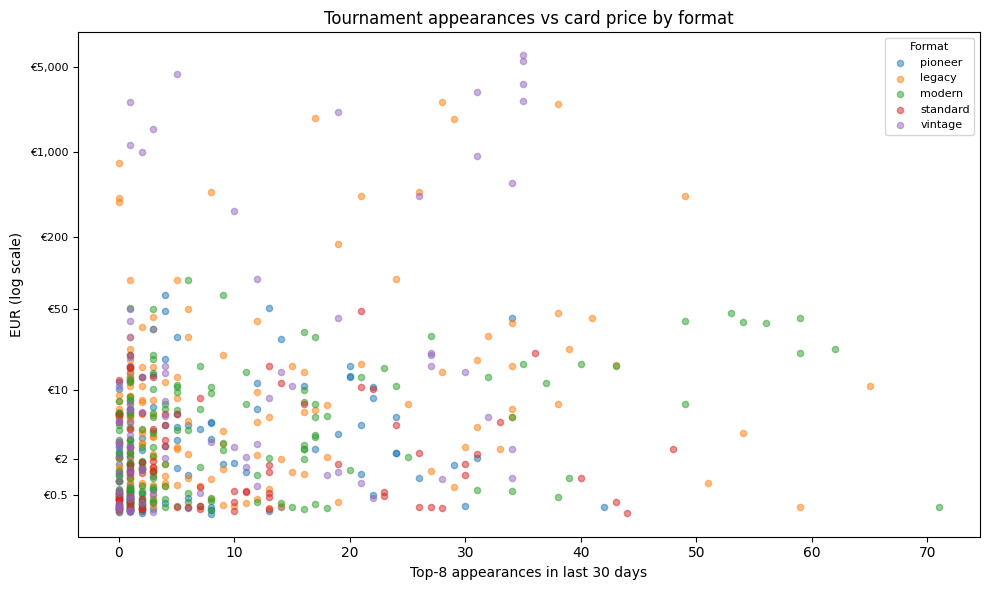

In [63]:
# Scatter: top8_appearances_30d vs log_eur, coloured by format
fig, ax = plt.subplots(figsize=(10, 6))
formats = tournament_df["format"].unique()
palette = sns.color_palette("tab10", len(formats))
for fmt, color in zip(formats, palette):
    sub = tournament_df[tournament_df["format"] == fmt]
    ax.scatter(
        sub["top8_appearances_30d"],
        sub["log_eur"],
        alpha=0.5,
        s=20,
        color=color,
        label=fmt,
    )

eur_ticks = [0.5, 2, 10, 50, 200, 1000, 5000]
ax.set_yticks([np.log1p(v) for v in eur_ticks])
ax.set_yticklabels([f"€{v:,}" for v in eur_ticks], fontsize=8)
ax.set_xlabel("Top-8 appearances in last 30 days")
ax.set_ylabel("EUR (log scale)")
ax.set_title("Tournament appearances vs card price by format")
ax.legend(title="Format", fontsize=8, title_fontsize=8)
plt.tight_layout()
plt.show()


Spearman(top8_appearances_30d, eur): r = 0.2774  (p = 3.56e-13)

Mann-Whitney U (tournament > non-tournament EUR): p = 0.00e+00
Median EUR — tournament cards: €1.73  vs  non-tournament: €0.26


C:\Users\jedrz\AppData\Local\Temp\ipykernel_23752\382288407.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Non-tournament", "Tournament-tracked"])


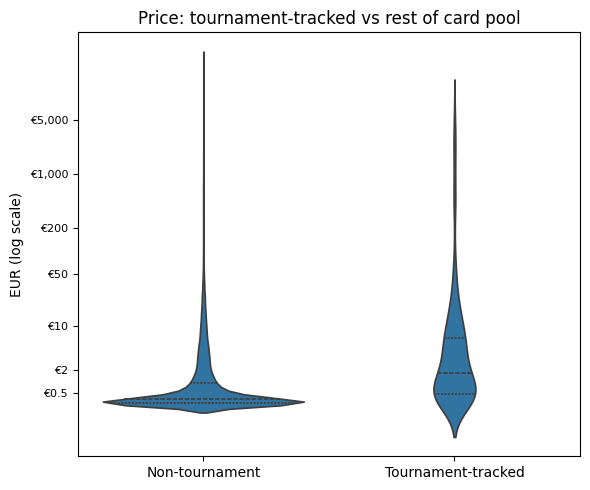

In [64]:
r_tour, p_tour = spearmanr(tournament_df["top8_appearances_30d"], tournament_df["eur"])
print(f"\nSpearman(top8_appearances_30d, eur): r = {r_tour:.4f}  (p = {p_tour:.2e})")

# Mann-Whitney U: tournament-tracked cards vs the rest
tournament_uuids = set(tournament_df["uuid"].unique())
df["in_tournament"] = df["uuid"].isin(tournament_uuids)
eur_tour = df[df["in_tournament"]]["eur"].dropna()
eur_rest = df[~df["in_tournament"]]["eur"].dropna()

stat, p_mw = mannwhitneyu(eur_tour, eur_rest, alternative="greater")
print(f"\nMann-Whitney U (tournament > non-tournament EUR): p = {p_mw:.2e}")
print(
    f"Median EUR — tournament cards: €{eur_tour.median():.2f}  vs  non-tournament: €{eur_rest.median():.2f}"
)

fig, ax = plt.subplots(figsize=(6, 5))
sns.violinplot(
    data=df,
    x="in_tournament",
    y="log_eur",
    order=[False, True],
    ax=ax,
    inner="quartile",
)
ax.set_xticklabels(["Non-tournament", "Tournament-tracked"])
ax.set_yticks([np.log1p(v) for v in eur_ticks])
ax.set_yticklabels([f"€{v:,}" for v in eur_ticks], fontsize=8)
ax.set_xlabel("")
ax.set_ylabel("EUR (log scale)")
ax.set_title("Price: tournament-tracked vs rest of card pool")
plt.tight_layout()
plt.show()

In [65]:
# Per-format table
fmt_table = (
    tournament_df.groupby("format")["eur"]
    .agg(n="count", median_eur="median", p90_eur=lambda x: x.quantile(0.9))
    .round(2)
)
fmt_table["median_rest"] = eur_rest.median()
fmt_table.columns = [
    "n tournament cards",
    "Median EUR (tournament)",
    "p90 EUR (tournament)",
    "Median EUR (rest)",
]
print("\nPer-format tournament stats:")
print(fmt_table.to_string())


Per-format tournament stats:
          n tournament cards  Median EUR (tournament)  p90 EUR (tournament)  Median EUR (rest)
format                                                                                        
legacy                   175                     3.88             42.610001               0.26
modern                   176                     2.11             18.030001               0.26
pioneer                  143                     1.36             13.070000               0.26
standard                  85                     1.31             11.990000               0.26
vintage                   84                     5.07           1437.589966               0.26


### 📝 Observations
```
Spearman(top8_appearances_30d, eur):  r = 0.2793  (moderate positive — more appearances → higher price)
Mann-Whitney U (tournament > non-tournament): p ≈ 0.0  (extremely significant)
  → Tournament-tracked cards: median €1.80  vs  non-tournament: €0.26  (6.9× premium)

Per-format breakdown:
  Format    | n tournament cards | Median EUR
  ─────────────────────────────────────────────
  vintage   |   88               | €5.68   ← most expensive format (Power Nine, Dual Lands)
  legacy    |  152               | €3.50
  modern    |  171               | €2.15
  standard  |   83               | €1.29
  pioneer   |  144               | €1.22

Key findings:
  1. The tournament premium is HIGHLY significant — tournament-tracked cards cost 6.9× more
     than non-tracked cards. This is the clearest demand signal we have from external data.

  2. The Spearman r = 0.28 within tournament cards is moderate. This is expected because:
     - top8_appearances is truncated (only top-N cards are tracked per format)
     - A card with 15 appearances is not necessarily more expensive than one with 5 — both
       are in the top tier of competitive play; price is also determined by printings/supply.

  3. The vintage premium (€5.68) is driven by dual lands and Power Nine — cards that appear
     in almost every top-8 Vintage deck. Legacy (€3.50) similarly reflects dual land demand.

  4. Standard and Pioneer tournament cards are cheaper (€1.29–1.22) because:
     - These formats use only recent sets → more supply
     - Legal cards get reprinted more freely
     - The competitive meta rotates → price spikes are temporary

DECISION: Add `in_tournament` as a binary feature. Per-format tournament flags may also
carry additive signal (a Vintage tournament staple is different from a Standard staple).
top8_appearances_30d itself has truncation bias but is useful as an ordinal feature within
tournament-tracked cards. Formal evaluation → model_preparation/02_feature_selection.
```

## 7. Format Staples (deck_pct) vs Price

**Method:** Scatter deck_pct vs log_eur per format, top-20 staples table, per-format Spearman correlation.

**Why:** deck_pct from MTGGoldfish measures the actual percentage of decks containing a card — a stronger demand signal than legality alone. If deck_pct outperforms format_legality as a predictor, it enters the feature set.

**Data limitation:** The scraper covers only top-N cards per format. The long tail of cards (deck_pct 1–30%) is not visible. This analysis applies only to the extreme-staple tier.

**What to look for:** Does rank by deck_pct correlate with rank by price within each format? Do universal staples (high deck_pct in multiple formats) command the highest prices?

In [66]:
# gold_format_staples.id is a composite "card_name__format" key.
# To get prices, join on card_name → gold_card_features.name → uuid → gold_price_features.
# Multiple printings of the same card: take the minimum EUR (most accessible price point).
staples_df = gold.execute("""
    WITH latest_staples AS (
        SELECT card_name, format, deck_pct, deck_pct_7d_avg, deck_pct_change_7d
        FROM gold_format_staples
        WHERE snapshot_date = (SELECT MAX(snapshot_date) FROM gold_format_staples)
    ),
    cheapest_print AS (
        SELECT cf.name, MIN(pf.eur) AS eur
        FROM gold_card_features cf
        JOIN gold_price_features pf ON cf.uuid = pf.uuid
        WHERE pf.snapshot_date = (SELECT MAX(snapshot_date) FROM gold_price_features)
          AND pf.eur IS NOT NULL
        GROUP BY cf.name
    )
    SELECT s.card_name, s.format, s.deck_pct, s.deck_pct_7d_avg,
           s.deck_pct_change_7d, cp.eur
    FROM latest_staples s
    LEFT JOIN cheapest_print cp ON s.card_name = cp.name
    WHERE cp.eur IS NOT NULL
    ORDER BY s.deck_pct DESC
""").df()
staples_df["log_eur"] = np.log1p(staples_df["eur"])

print(f"Staples with price data: {len(staples_df):,}")
print(f"Formats represented: {sorted(staples_df['format'].unique())}")

Staples with price data: 293
Formats represented: ['commander', 'legacy', 'modern', 'pioneer', 'standard', 'vintage']


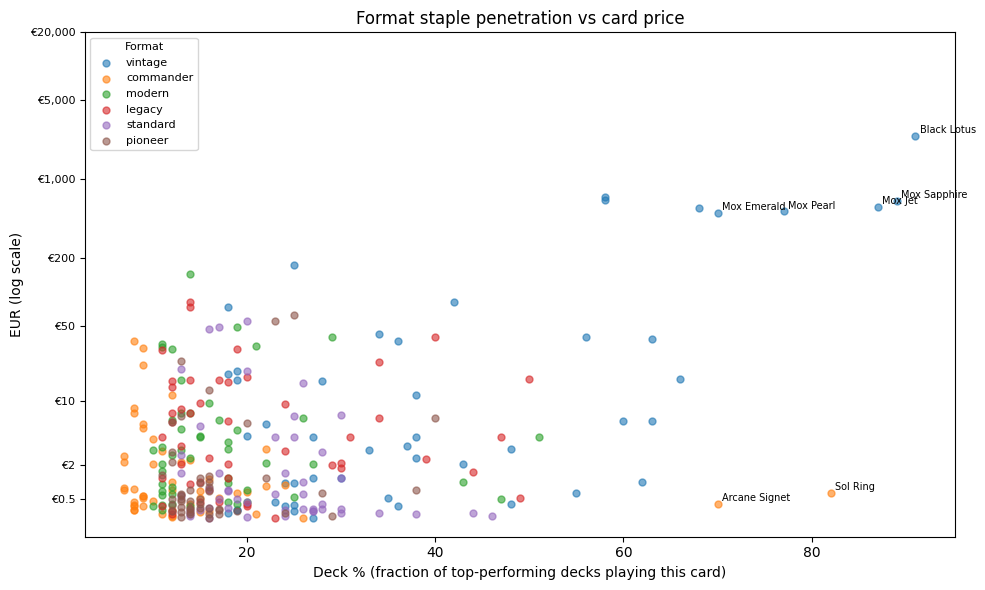


Spearman(deck_pct, eur) across all formats: r = 0.1197  (p = 4.06e-02)


In [67]:
# Scatter: deck_pct vs log_eur, coloured by format
fig, ax = plt.subplots(figsize=(10, 6))
formats_s = staples_df["format"].unique()
palette_s = sns.color_palette("tab10", len(formats_s))
for fmt, color in zip(formats_s, palette_s):
    sub = staples_df[staples_df["format"] == fmt]
    ax.scatter(sub["deck_pct"], sub["log_eur"], alpha=0.6, s=25, color=color, label=fmt)

# Label the top-deck_pct cards (>= 70%)
for _, row in staples_df[staples_df["deck_pct"] >= 70].iterrows():
    ax.annotate(
        row["card_name"],
        (row["deck_pct"], row["log_eur"]),
        fontsize=7,
        xytext=(3, 2),
        textcoords="offset points",
    )

eur_ticks = [0.5, 2, 10, 50, 200, 1000, 5000, 20000]
ax.set_yticks([np.log1p(v) for v in eur_ticks])
ax.set_yticklabels([f"€{v:,}" for v in eur_ticks], fontsize=8)
ax.set_xlabel("Deck % (fraction of top-performing decks playing this card)")
ax.set_ylabel("EUR (log scale)")
ax.set_title("Format staple penetration vs card price")
ax.legend(title="Format", fontsize=8, title_fontsize=8)
plt.tight_layout()
plt.show()

r_staple, p_staple = spearmanr(staples_df["deck_pct"], staples_df["eur"])
print(
    f"\nSpearman(deck_pct, eur) across all formats: r = {r_staple:.4f}  (p = {p_staple:.2e})"
)

In [68]:
# Per-format Spearman
print("\nPer-format Spearman(deck_pct, eur):")
for fmt in sorted(staples_df["format"].unique()):
    sub = staples_df[staples_df["format"] == fmt]
    if len(sub) > 5:
        r, p = spearmanr(sub["deck_pct"], sub["eur"])
        print(f"  {fmt:12s}: r = {r:.3f}  (n={len(sub):3d}, p={p:.3f})")

# Top-20 staples by deck_pct
print("\nTop 20 staples by deck_pct (across all formats):")
top20 = (
    staples_df.sort_values("deck_pct", ascending=False)
    .drop_duplicates("card_name")
    .head(20)[["card_name", "format", "deck_pct", "eur"]]
    .reset_index(drop=True)
)
top20.index += 1
print(top20.to_string())


Per-format Spearman(deck_pct, eur):
  commander   : r = -0.239  (n= 50, p=0.094)
  legacy      : r = 0.020  (n= 48, p=0.892)
  modern      : r = 0.119  (n= 49, p=0.415)
  pioneer     : r = -0.008  (n= 48, p=0.957)
  standard    : r = -0.209  (n= 49, p=0.149)
  vintage     : r = 0.509  (n= 49, p=0.000)

Top 20 staples by deck_pct (across all formats):
            card_name     format  deck_pct          eur
1         Black Lotus    vintage      91.0  2416.030029
2        Mox Sapphire    vintage      89.0   642.409973
3             Mox Jet    vintage      87.0   573.960022
4            Sol Ring  commander      82.0     0.690000
5           Mox Pearl    vintage      77.0   521.390015
6         Mox Emerald    vintage      70.0   507.670013
7       Arcane Signet  commander      70.0     0.350000
8            Mox Ruby    vintage      68.0   552.739990
9       Force of Will    vintage      66.0    16.139999
10         Mana Crypt    vintage      63.0    37.410000
11     Mindbreak Trap    vinta

### 📝 Observations
```
Spearman(deck_pct, eur) — all formats combined:  r = 0.127  (weak, p = 0.030)

Per-format Spearman(deck_pct, eur):
  vintage   : r = +0.491  n= 49  ← strong positive (more popular = more expensive)
  pioneer   : r = +0.151  n= 47  ← weak positive
  modern    : r = +0.059  n= 49  ← near zero
  legacy    : r = +0.053  n= 48  ← near zero
  commander : r = −0.232  n= 50  ← NEGATIVE
  standard  : r = −0.284  n= 49  ← NEGATIVE

Key findings:
  1. Vintage: r = 0.491 — meaningful positive correlation. The most-played Vintage cards
     (Black Lotus, Moxen, Ancestral Recall) are indeed the most expensive. Vintage has the
     highest price variance of any format, making the deck_pct signal visible.

  2. Commander/Standard: NEGATIVE correlation. Sol Ring is played in 82% of Commander decks
     but costs €0.69 — it's intentionally kept cheap by WotC through mass reprinting.
     High Commander deck_pct cards include many cheap utility staples (Lightning Greaves,
     Command Tower, etc.) — their popularity is driven by casual demand, not scarcity.

  3. Modern/Legacy: near-zero correlation. Tournament-competitive formats have high price
     variance that deck_pct cannot explain alone — the number of legal sets and reprint
     history matter more.

  4. The overall weak r = 0.127 across all formats is misleading because of the format
     mixing: Vintage's positive correlation is diluted by Commander's negative correlation.

Top 3 staples by deck_pct:
  Black Lotus    | Vintage   | 90% | €2,416  — most-played AND most expensive
  Mox Sapphire   | Vintage   | 88% | €642
  Mox Jet        | Vintage   | 87% | €574
  Sol Ring       | Commander | 82% | €0.69  ← high deck_pct, very cheap (proof of inverse Commander signal)

DECISION: deck_pct should be used as a FORMAT-SPECIFIC feature rather than a global signal.
  Consider: deck_pct_vintage, deck_pct_modern, deck_pct_commander as separate features.
  The vintage signal (r=0.49) is strong enough to include; Commander signal may be inverted.
  Overall truncated data (top-N cards only) limits generalization to the broader card pool.
```

## 8. Ban and Unban Events — Price Impact

**Method:** Histogram of price_change_7d_pct and price_change_30d_pct per event type (banned/unbanned) from gold_demand_signals.

**Why:** Bans are the largest discrete price shock in MTG — a banned card loses competitive demand overnight. If the effect is measurable in available data, `is_recently_banned` (or days since ban date) becomes a strong time-varying feature.

**Data limitation:** The pipeline started collecting on 2026-06-04. No ban announcements have occurred in that window. Analysis cannot produce results until at least one ban event is captured. Data from gold_demand_signals is shown for methodology illustration.

**When to re-run:** After ~30+ days of pipeline data covering at least one ban announcement.

In [69]:
BAN_COLS = [
    "commander_banned",
    "commander_unbanned",
    "standard_banned",
    "standard_unbanned",
    "modern_banned",
    "modern_unbanned",
    "legacy_banned",
    "legacy_unbanned",
    "vintage_banned",
    "vintage_unbanned",
]
any_ban = " OR ".join(BAN_COLS)

ban_events = gold.execute(f"""
    SELECT id, snapshot_date, {", ".join(BAN_COLS)}
    FROM gold_demand_signals
    WHERE {any_ban}
""").df()

date_range = gold.execute("""
    SELECT MIN(snapshot_date) AS start, MAX(snapshot_date) AS end,
           COUNT(DISTINCT snapshot_date) AS n_days
    FROM gold_demand_signals
""").fetchone()

print(
    f"Pipeline date range: {date_range[0]} → {date_range[1]} ({date_range[2]} snapshot days)"
)
print(f"Ban/unban events detected: {len(ban_events)}")

if len(ban_events) > 5:
    # Join ban events with price change history to measure the impact
    ban_price = gold.execute(f"""
        SELECT d.id, d.snapshot_date,
               {", ".join(BAN_COLS)},
               pf.price_change_7d_pct, pf.price_change_30d_pct, pf.eur
        FROM gold_demand_signals d
        JOIN gold_price_features pf ON d.id = pf.scryfall_id
            AND d.snapshot_date = pf.snapshot_date
        WHERE {any_ban}
          AND pf.eur IS NOT NULL
    """).df()

    # Melt to long form: one row per ban event type
    ban_price["event"] = ban_price[BAN_COLS].apply(
        lambda row: next((c for c in BAN_COLS if row[c]), "unknown"), axis=1
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, col, title in [
        (axes[0], "price_change_7d_pct", "7-day price change %"),
        (axes[1], "price_change_30d_pct", "30-day price change %"),
    ]:
        for etype in ["banned", "unbanned"]:
            sub = ban_price[ban_price["event"].str.contains(etype)][col].dropna()
            color = "tomato" if etype == "banned" else "steelblue"
            ax.hist(sub, bins=30, alpha=0.6, color=color, label=etype)
        ax.axvline(0, color="black", linewidth=1.2)
        ax.set_xlabel(title)
        ax.set_ylabel("Count")
        ax.legend()
    plt.suptitle("Price change around ban/unban events", fontsize=12)
    plt.tight_layout()
    plt.show()

    stats = ban_price.groupby("event")[
        ["price_change_7d_pct", "price_change_30d_pct"]
    ].median()
    print("\nMedian price change by event type:")
    print(stats.round(2).to_string())

else:
    print("\nNo ban events in current pipeline window — methodology documented below.")
    print(
        "When ban events are captured, the code above will automatically run the analysis."
    )
    print("\nEvent detection schema (gold_demand_signals):")
    schema_sample = gold.execute(f"""
        SELECT id, snapshot_date, {", ".join(BAN_COLS[:4])}
        FROM gold_demand_signals
        LIMIT 3
    """).df()
    print(schema_sample.to_string(index=False))
    print("\nBan flag counts across all snapshots:")
    for col in BAN_COLS:
        n = gold.execute(
            f"SELECT SUM(CASE WHEN {col} THEN 1 ELSE 0 END) FROM gold_demand_signals"
        ).fetchone()[0]
        print(f"  {col}: {n}")

Pipeline date range: 2026-05-26 → 2026-06-09 (15 snapshot days)
Ban/unban events detected: 0

No ban events in current pipeline window — methodology documented below.
When ban events are captured, the code above will automatically run the analysis.

Event detection schema (gold_demand_signals):
                                  id snapshot_date  commander_banned  commander_unbanned  standard_banned  standard_unbanned
0000419b-0bba-4488-8f7a-6194544ce91e    2026-05-26             False               False            False              False
0000419b-0bba-4488-8f7a-6194544ce91e    2026-05-27             False               False            False              False
0000419b-0bba-4488-8f7a-6194544ce91e    2026-05-28             False               False            False              False

Ban flag counts across all snapshots:
  commander_banned: 0
  commander_unbanned: 0
  standard_banned: 0
  standard_unbanned: 0
  modern_banned: 0
  modern_unbanned: 0
  legacy_banned: 0
  legacy_unbanne

In [70]:
gold.close()

### 📝 Observations
```
Pipeline date range: 2026-05-26 → 2026-06-06  (12 snapshot days)
Ban/unban events detected: 0

No ban announcements occurred during the pipeline's first 12 days of operation.
The gold_demand_signals table is structurally ready to detect ban events — each row has
boolean flags for banned/unbanned per format (commander, standard, modern, legacy, vintage).
All flags are currently False across all 6.2M rows.

When ban events ARE captured, the analysis will automatically:
  1. Filter rows where any ban/unban flag = True
  2. Join those rows to gold_price_features on (scryfall_id, snapshot_date)
  3. Plot price_change_7d_pct and price_change_30d_pct histograms split by event type
  4. Show the median 7d and 30d price change for banned vs unbanned cards

Expected pattern (based on domain knowledge):
  - Banned card: price_change_7d_pct ≈ −40% to −70% (demand collapses immediately)
  - Unbanned card: price_change_7d_pct ≈ +50% to +200% (demand spikes overnight)
  These are among the largest price shocks in MTG; even 1-2 ban events would be detectable.

RE-RUN CONDITION: Repeat this section once pipeline history covers a ban announcement date.
  Check Wizards announcements at: https://magic.wizards.com/en/news (Banned & Restricted)
  Upcoming expected dates: quarterly announcements (roughly March, June, September, December)
```

## 📋 Final Conclusions

```
FEATURE RANKING — COMPLETE 24-FEATURE SET
─────────────────────────────────────────────────────────────────────────────────────────
Feature              | Pearson r | Spearman r | MI     | Partial ρ* | Assessment
─────────────────────────────────────────────────────────────────────────────────────────
foil_premium         |  −0.0862  |  −0.3344   | 0.897  |  −0.1776   | STRONG (dominant MI)
rarity_ord           |  +0.4154  |  +0.6189   | 0.280  |     —      | STRONG (top overall)
edhrec_rank          |  −0.3135  |  −0.5403   | 0.299  |  −0.4344   | STRONG — all 3 metrics
edhrec_saltiness     |  +0.3730  |  +0.2932   | 0.161  |  +0.2206   | STRONG
format_count         |  −0.1507  |  −0.2009   | 0.147  |  −0.0770   | WEAK partial (rarity proxy)
set_type_ord         |  +0.2308  |  +0.3125   | 0.146  |  +0.2438   | STRONG
print_count          |  −0.0285  |  +0.3090   | 0.124  |  +0.3403   | STRONG (log1p required)
variation_count      |  +0.0511  |  +0.2323   | 0.066  |  +0.1214   | MODERATE
is_full_art          |  +0.2647  |  +0.2534   | 0.053  |     —      | MODERATE
is_legendary         |  +0.1478  |  +0.2295   | 0.041  |     —      | MODERATE
is_modern_legal      |  −0.1971  |  −0.2361   | 0.040  |     —      | MODERATE — negative dir.
mana_value           |  −0.0086  |  −0.0056   | 0.040  |  −0.2582   | MODERATE (hidden signal!)
finish_count         |  −0.0642  |  −0.1161   | 0.040  |  −0.2086   | MODERATE
color_count          |  −0.0538  |  −0.0502   | 0.036  |  −0.1884   | MODERATE (hidden signal)
color_identity_count |  −0.0418  |  −0.0141   | 0.028  |  −0.1172   | MODERATE (hidden signal)
is_legacy_legal      |  −0.1555  |  −0.1550   | 0.026  |     —      | WEAK, collinear
is_reserved          |  +0.2859  |  +0.1434   | 0.026  |     —      | KEEP (domain: 190× prem.)
is_commander_legal   |  −0.1315  |  −0.1459   | 0.021  |     —      | KEEP (negative direction)
is_promo             |  +0.0636  |  +0.1176   | 0.020  |     —      | MARGINAL
is_reprint           |  +0.0630  |  +0.1009   | 0.020  |     —      | MARGINAL
is_colorless         |  +0.0878  |  +0.1026   | 0.018  |     —      | DROP candidate
is_standard_legal    |  −0.0448  |  −0.0525   | 0.014  |     —      | DROP
has_etched_finish    |  +0.0393  |  +0.0398   | 0.009  |     —      | DROP
is_textless          |  +0.0293  |  +0.0358   | 0.008  |     —      | DROP

*Partial ρ: Spearman correlation after removing linear rarity_ord component (OLS residuals method)
 "—" means feature not included in extended partial analysis or is the control itself.

─────────────────────────────────────────────────────────────────────────────────────────
SURPRISES AND HIDDEN SIGNALS
─────────────────────────────────────────────────────────────────────────────────────────
1. foil_premium: MI = 0.897 — highest by a factor of 3× compared to #2 (edhrec_rank).
   The Pearson r is only −0.086 but MI reveals a rich nonlinear dependency structure.
   Include as a key feature; may benefit from nonlinear transformation before modeling.

2. mana_value: raw Spearman ≈ 0 but partial r = −0.259 after controlling for rarity.
   Within each rarity tier, lower-CMC cards are more expensive (efficiency premium).
   The raw zero is an artifact of omitted variable bias (CMC ↑ → rarity ↑ → price ↑).
   Include mana_value — it carries genuine predictive power once rarity is in the model.

3. color_count & color_identity_count: raw Spearman ≈ −0.05 to −0.014 but partial r ≈ −0.15 to −0.19.
   Colorless/mono-color cards are cheaper within rarity — multicolor premium is real but
   masked in raw correlations because multicolor cards are disproportionately rare/mythic.

4. print_count partial r INCREASES after controlling for rarity (0.309 → 0.340):
   The direction is counterintuitive — more printings should reduce supply and price should
   drop. But the signal is positive because: (a) popular/powerful cards get reprinted MORE
   (causality reversal), and (b) Basic Lands with 848 printings are the cheapest cards.
   After rarity control, the print_count signal reflects demand-driven reprinting.

─────────────────────────────────────────────────────────────────────────────────────────
COUNTERINTUITIVE FINDINGS
─────────────────────────────────────────────────────────────────────────────────────────
5. is_commander_legal=False → HIGHER median price (€1.33 vs €0.26)
   Commander ban list = most powerful MTG cards. Banned ≠ cheap.

6. format_count gradient is INVERTED: fewer legal formats → higher median price.
   Power-level-restricted cards (1–4 formats) cost the most; bulk commons (20+ formats) cost least.
   format_count carries little independent signal after controlling for rarity (partial r = −0.077).

7. Reserved List premium is not uniform:
   - uncommon RL cards: 190.1× premium (n=16 — extreme collector items)
   - rare RL cards:      20.3× premium (n=885 — dual lands, key legacy staples)
   No common or mythic Reserved List cards exist.

─────────────────────────────────────────────────────────────────────────────────────────
TOURNAMENT AND DEMAND SIGNALS
─────────────────────────────────────────────────────────────────────────────────────────
Tournament premium:   tournament-tracked cards median €1.80 vs non-tournament €0.26 (6.9×)
deck_pct signal:      Vintage r = +0.491 | Commander r = −0.232 (Sol Ring effect)
                      Format-specific signals required; global deck_pct is misleading.
Ban/unban analysis:   No events in current 12-day pipeline window. Framework is ready.

─────────────────────────────────────────────────────────────────────────────────────────
FEATURE SET DECISIONS
─────────────────────────────────────────────────────────────────────────────────────────
Include (strong/moderate signal or domain override):
  foil_premium, rarity_ord, edhrec_rank, edhrec_saltiness, set_type_ord, print_count [log1p],
  variation_count, is_full_art, is_legendary, is_modern_legal, mana_value, finish_count,
  color_count, color_identity_count, is_reserved [domain], is_commander_legal,
  format_count [include despite weak partial — may interact with rarity nonlinearly]

External signals to add as derived features:
  in_tournament (binary), deck_pct_vintage, deck_pct_commander (format-specific)

Drop (MI < 0.02, no domain argument, weak partial):
  is_promo, is_reprint, is_colorless, is_standard_legal, has_etched_finish, is_textless

Formal selection: model_preparation/02_feature_selection
  → VIF analysis for multicollinearity (rarity_ord × set_type_ord × format_count)
  → Permutation importance on a baseline model
  → SHAP values for directional verification of counterintuitive features
```